# Jointure Maths × Portugais — comparer les mêmes élèves dans deux matières

## L'idée

Les deux fichiers `student-mat.csv` et `student-por.csv` ne sont pas deux populations disjointes : une
partie des élèves apparaît **dans les deux**, une fois comme élève de Maths et une fois comme élève de
Portugais. Le jeu de données ne fournit aucun identifiant — mais on peut reconstruire ce lien en
remarquant qu'un même élève partage forcément un certain nombre d'attributs **stables**, qui ne dépendent
ni du cours suivi ni du moment du sondage : son établissement, son sexe, son âge, son adresse, la
structure de sa famille, le niveau d'étude et la profession de ses parents...

C'est la technique documentée dans l'article original de Cortez & Silva sur ce jeu de données : une
jointure sur un sous-ensemble d'attributs démographiques/familiaux retrouve un noyau d'élèves communs aux
deux cours, ce qui permet de poser une question impossible à traiter dans l'un ou l'autre fichier pris
isolément : **comment un même élève se comporte-t-il et réussit-il selon la matière ?**

## Les attributs choisis pour la clé de jointure

On retient 13 attributs : `school`, `sex`, `age`, `address`, `famsize`, `Pstatus`, `Medu`, `Fedu`,
`Mjob`, `Fjob`, `reason`, `nursery`, `internet`.

Le critère de sélection est simple : ce sont des attributs **biographiques ou familiaux**, fixés bien
avant l'inscription au cours (le métier des parents, la structure familiale, la fréquentation de la
crèche...) ou définis une fois pour toutes pour l'année scolaire (l'établissement, l'adresse, l'accès à
internet à la maison). À l'inverse, on exclut volontairement tout ce qui pourrait varier d'un cours à
l'autre ou d'un moment à l'autre du sondage — `studytime`, `goout`, `failures`, les notes, etc. — car ce
sont justement les variables qu'on veut comparer *après* la jointure, pas des clés d'identification.

## Ce qu'on va en faire

1. Effectuer la jointure et vérifier qu'on retombe sur le nombre d'élèves communs documenté pour ce jeu
   de données (un signal fort que la méthode est la bonne)
2. **Valider** la jointure : si la clé identifie vraiment les mêmes individus, alors les variables
   *non utilisées dans la clé* mais qui ne devraient elles non plus pas changer d'un cours à l'autre
   (`Dalc`, `goout`, `famrel`...) devraient se retrouver identiques dans les deux enregistrements — un
   test de cohérence interne qui sert à la fois de garde-fou et de première découverte
3. Gérer la part d'ambiguïté inévitable d'une clé qui n'est pas un identifiant unique
4. Comparer, pour les mêmes élèves, leurs résultats en Maths et en Portugais

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

student_mat = pd.read_csv("../donnees/student-mat.csv")
student_por = pd.read_csv("../donnees/student-por.csv")

print(f"student-mat : {student_mat.shape[0]} élèves, {student_mat.shape[1]} colonnes")
print(f"student-por : {student_por.shape[0]} élèves, {student_por.shape[1]} colonnes")
print(f"Colonnes identiques dans les deux fichiers : {list(student_mat.columns) == list(student_por.columns)}")

student-mat : 395 élèves, 33 colonnes
student-por : 649 élèves, 33 colonnes
Colonnes identiques dans les deux fichiers : True


## 1. Effectuer la jointure

On fusionne les deux tables sur les 13 attributs retenus. `pandas.merge` produit alors une ligne pour
chaque **paire** (ligne de `student-mat`, ligne de `student-por`) dont les 13 attributs coïncident — donc,
si la clé est un bon identifiant, une ligne par élève commun, avec ses informations Maths et Portugais
côte à côte (suffixes `_mat` / `_por` pour distinguer les colonnes partagées comme `G1`, `goout`, etc.).

In [4]:
JOIN_COLS = ["school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
             "Mjob", "Fjob", "reason", "nursery", "internet"]

merged = pd.merge(student_mat, student_por, on=JOIN_COLS, suffixes=('_mat', '_por'))

print(f"Lignes obtenues par la jointure : {len(merged)}")
print(f"  (sur {len(student_mat)} élèves de Maths et {len(student_por)} élèves de Portugais)")
print()
print("Aperçu — un même profil démographique, deux dossiers scolaires :")
display_cols = JOIN_COLS[:4] + ['G1_mat', 'G2_mat', 'G3_mat', 'G1_por', 'G2_por', 'G3_por']
print(merged[display_cols].head(5).to_string(index=False))

merged.to_csv("student.csv")

Lignes obtenues par la jointure : 382
  (sur 395 élèves de Maths et 649 élèves de Portugais)

Aperçu — un même profil démographique, deux dossiers scolaires :
school sex  age address  G1_mat  G2_mat  G3_mat  G1_por  G2_por  G3_por
    GP   F   18       U       5       6       6       0      11      11
    GP   F   17       U       5       5       6       9      11      11
    GP   F   15       U       7       8      10      12      13      12
    GP   F   15       U      15      14      15      14      14      14
    GP   F   16       U       6      10      10      11      13      13


## 2. Repérer l'ambiguïté résiduelle

**382** lignes — c'est exactement le nombre documenté dans la littérature sur ce jeu de données pour
cette jointure précise. Un signe encourageant... mais avant de crier victoire, il faut regarder de plus
près *comment* cette fusion a été construite. Une clé démographique n'est pas un identifiant unique : rien
n'empêche deux élèves **réellement distincts** de partager exactement le même profil sur ces 13 attributs
(même établissement, même âge, même sexe, mêmes parents aux mêmes professions...). Quand cela arrive,
`pandas.merge` produit un **produit cartésien** local — chaque ligne `mat` du profil est associée à
chaque ligne `por` du même profil, générant des paires qui ne correspondent peut-être à aucun individu réel.

In [5]:
profile_sizes = merged.groupby(JOIN_COLS).size()
print("Nombre de paires générées par profil démographique :")
print(profile_sizes.value_counts().sort_index().rename_axis('paires/profil').rename('nb de profils').to_string())
print()

clean_keys = set(map(tuple, profile_sizes[profile_sizes == 1].index.to_frame(index=False).values.tolist()))
is_clean = merged[JOIN_COLS].apply(tuple, axis=1).isin(clean_keys)

n_ambiguous_profiles = (profile_sizes > 1).sum()
clean = merged[is_clean].reset_index(drop=True)
ambiguous = merged[~is_clean].reset_index(drop=True)

print(f"{n_ambiguous_profiles} profils sont partagés par plusieurs élèves, générant {len(ambiguous)} paires "
      f"« fantômes » (toutes les associations possibles élève-Maths × élève-Portugais pour ce profil — "
      f"sans garantie qu'elles désignent le même individu)")
print(f"Il reste {len(clean)} paires non ambiguës — un seul élève de Maths et un seul élève de Portugais "
      f"partagent ce profil, l'identification est donc certaine *si la clé est fiable*.")
print()
print("Reste à vérifier que cette dernière hypothèse — que la clé identifie vraiment les mêmes individus — "
      "tient la route. C'est l'objet de la section suivante.")

Nombre de paires générées par profil démographique :
paires/profil
1    358
2      4
4      4

8 profils sont partagés par plusieurs élèves, générant 24 paires « fantômes » (toutes les associations possibles élève-Maths × élève-Portugais pour ce profil — sans garantie qu'elles désignent le même individu)
Il reste 358 paires non ambiguës — un seul élève de Maths et un seul élève de Portugais partagent ce profil, l'identification est donc certaine *si la clé est fiable*.

Reste à vérifier que cette dernière hypothèse — que la clé identifie vraiment les mêmes individus — tient la route. C'est l'objet de la section suivante.


## 3. Valider la jointure : un test de cohérence interne

Voici l'idée du test : parmi les variables **qui ne font pas partie de la clé**, certaines décrivent
malgré tout des faits stables — la consommation d'alcool en semaine (`Dalc`), la fréquence des sorties
(`goout`), la qualité des relations familiales (`famrel`), le statut amoureux (`romantic`)... Si une paire
réunit vraiment le même individu, on s'attend à retrouver pour chacune de ces variables **la même valeur**
côté Maths et côté Portugais — alors même qu'elles n'ont servi à rien dans la fusion. À l'inverse, une
coïncidence démographique entre deux personnes différentes ne donne aucune raison de coïncider sur ces
variables-là : leur taux d'accord devrait retomber proche du hasard.

C'est exactement la situation qu'on a sous la main : on dispose maintenant de deux groupes de paires —
les 358 « propres » (`clean`, identification certaine si la clé est bonne) et les 24 « fantômes »
(`ambiguous`, association arbitraire au sein d'un profil partagé). **Si la clé fonctionne, le contraste
entre ces deux groupes doit être spectaculaire** : cohérence quasi parfaite d'un côté, quasi aléatoire de
l'autre. C'est un test bien plus parlant qu'un simple décompte de lignes.

On exclut de ce test les variables *intrinsèquement* liées au cours suivi — `paid` (cours payants dans
*cette* matière), `absences` (absences dans *ce* cours), `failures` (échecs antérieurs, qui peuvent
légitimement différer d'une matière à l'autre) — ainsi que les notes, qui sont l'objet même de la
comparaison à venir.

In [41]:
# Variables hors clé, ressaisies dans les deux enquêtes, et a priori stables (indépendantes du cours)
CHECK_COLS = ['guardian', 'traveltime', 'studytime', 'schoolsup', 'famsup', 'activities',
              'higher', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

print(f"Taux de cohérence (même réponse côté Maths et côté Portugais), comparé entre les deux groupes :\n")
print(f"  {'variable':12s} {'clean (n=358)':>15s} {'ambiguous (n=24)':>18s}")
for col in CHECK_COLS:
    sc = (clean[col + '_mat'] == clean[col + '_por']).mean()
    sa = (ambiguous[col + '_mat'] == ambiguous[col + '_por']).mean()
    print(f"  {col:12s} {sc*100:14.1f}% {sa*100:17.1f}%")

print()
print("Pour comparaison, deux variables *attendues* différentes car spécifiques au cours suivi (sur l'ensemble "
      "des 382 paires) :")
for col in ['paid', 'absences']:
    same = (merged[col + '_mat'] == merged[col + '_por']).mean()
    print(f"  {col:12s} : {same*100:5.1f}% identiques")
print()
print("Et `failures` (échecs antérieurs — peut légitimement différer d'une matière à l'autre) :")
same_fail = (merged['failures_mat'] == merged['failures_por']).mean()
print(f"  failures     : {same_fail*100:5.1f}% identiques")

Taux de cohérence (même réponse côté Maths et côté Portugais), comparé entre les deux groupes :

  variable       clean (n=358)   ambiguous (n=24)
  guardian              100.0%              75.0%
  traveltime            100.0%              79.2%
  studytime             100.0%              62.5%
  schoolsup             100.0%              87.5%
  famsup                100.0%              79.2%
  activities            100.0%              79.2%
  higher                100.0%              83.3%
  romantic              100.0%              75.0%
  famrel                100.0%              58.3%
  freetime              100.0%              54.2%
  goout                 100.0%              58.3%
  Dalc                  100.0%              79.2%
  Walc                  100.0%              50.0%
  health                100.0%              66.7%

Pour comparaison, deux variables *attendues* différentes car spécifiques au cours suivi (sur l'ensemble des 382 paires) :
  paid         :  55.2% identi

**Le contraste est total, et il tranche la question.** Sur les 358 paires `clean`, les 14 variables
comportementales et familiales — qui n'ont *strictement aucun rôle* dans la clé de jointure — coïncident
à **100%**, sans une seule exception. Sur les 24 paires `ambiguous`, en revanche, le taux d'accord
s'effondre et oscille entre 50% et 87% selon la variable — c'est-à-dire grosso modo le niveau qu'on
obtiendrait en associant deux personnes au hasard au sein d'un même profil démographique (`Walc`, à 5
modalités, tombe ainsi à 50% ; `freetime` et `famrel` à ~55-58%).

Ce contraste est la preuve la plus solide qu'on puisse espérer :

- Les **358 paires propres** ne sont pas seulement « les paires sans ambiguïté de profil » — elles sont
  *réellement* les mêmes 358 individus. Une cohérence de 100% sur 14 variables indépendantes de la clé
  n'a aucune chance raisonnable d'être une coïncidence.
- Les **24 paires fantômes**, à l'inverse, se comportent exactement comme des associations arbitraires :
  leur taux d'accord proche du hasard confirme qu'elles réunissent souvent des individus différents qui
  partagent simplement un profil démographique commun.

La cohérence parfaite révèle aussi un fait sur la collecte des données elle-même : ces variables
comportementales n'ont pas été ressaisies indépendamment à chaque enquête, mais proviennent d'une seule
fiche par élève, dupliquée dans les deux fichiers — une mesure unique, pas deux mesures indépendantes
(ce qui interdit, par exemple, d'utiliser cette redondance comme un test de fiabilité du déclaratif).
Les deux variables qui s'écartent légitimement de ce schéma le confirment en creux : `paid` et `absences`
sont *par construction* spécifiques au cours suivi, et `failures` peut légitimement différer d'une
matière à l'autre.

**On poursuit donc l'analyse sur les 358 paires `clean`** — une base fiable à 100%, débarrassée des
24 associations fantômes qui auraient pollué toute comparaison fine.

### Zoom — la consommation d'alcool, colonne par colonne

`Dalc` (consommation en semaine) et `Walc` (consommation le week-end) faisaient partie du test de
cohérence ci-dessus, et affichaient déjà 100% d'accord. Elles méritent un coup de projecteur à part :
ce sont précisément les deux variables qui servent à construire `classe_alcool`, la cible de
`apprentissage_alcool.ipynb` — la cohérence parfaite entre les deux enregistrements de chaque élève est
donc une garantie directe que cette cible serait identique, qu'on la construise à partir de
`student-mat` ou de `student-por`, pour les 358 élèves communs aux deux.

On regarde ici, modalité par modalité, la table de contingence entre la version « Maths » et la version
« Portugais » de chacune des deux colonnes — et, pour faire bonne mesure, le score combiné
`Dalc × 2 + Walc` utilisé dans `classe_alcool`.

In [42]:
for col in ['Dalc', 'Walc']:
    same = (clean[col + '_mat'] == clean[col + '_por']).sum()
    print(f"--- {col} : {same}/{len(clean)} valeurs identiques ({same/len(clean)*100:.1f}%) ---")
    ct = pd.crosstab(clean[col + '_mat'], clean[col + '_por'],
                     rownames=[f'{col}_mat'], colnames=[f'{col}_por'])
    print(ct.to_string())
    print(f"  → table parfaitement diagonale : {(np.diag(ct).sum() == ct.values.sum())}\n")

score_mat = clean['Dalc_mat'] * 2 + clean['Walc_mat']
score_por = clean['Dalc_por'] * 2 + clean['Walc_por']
n_same_score = (score_mat == score_por).sum()
print(f"Score combiné `Dalc×2 + Walc` (celui utilisé pour `classe_alcool`) : "
      f"{n_same_score}/{len(clean)} identiques ({n_same_score/len(clean)*100:.1f}%)")
print(f"Distribution des écarts (mat − por) : {dict(sorted((score_mat - score_por).value_counts().items()))}")

clean.to_csv("student_clean.csv")

--- Dalc : 358/358 valeurs identiques (100.0%) ---
Dalc_por    1   2   3  4  5
Dalc_mat                   
1         248   0   0  0  0
2           0  69   0  0  0
3           0   0  24  0  0
4           0   0   0  8  0
5           0   0   0  0  9
  → table parfaitement diagonale : True

--- Walc : 358/358 valeurs identiques (100.0%) ---
Walc_por    1   2   3   4   5
Walc_mat                     
1         136   0   0   0   0
2           0  75   0   0   0
3           0   0  74   0   0
4           0   0   0  46   0
5           0   0   0   0  27
  → table parfaitement diagonale : True

Score combiné `Dalc×2 + Walc` (celui utilisé pour `classe_alcool`) : 358/358 identiques (100.0%)
Distribution des écarts (mat − por) : {0: 358}


**Le résultat est sans la moindre nuance : 358 valeurs identiques sur 358, pour `Dalc` comme pour
`Walc`** — les deux tables de contingence sont **parfaitement diagonales**, sans le moindre écart hors
diagonale. Et comme `Dalc` et `Walc` coïncident individuellement, leur combinaison (`Dalc × 2 + Walc`,
le score qui définit `classe_alcool`) coïncide elle aussi pour les 358 paires, sans exception.

Cela confirme un point déjà soulevé en section 3, mais avec une portée concrète cette fois : **la
consommation d'alcool déclarée par un élève est rigoureusement la même, qu'on la lise dans son dossier de
Maths ou dans son dossier de Portugais.** Ce n'est pas une coïncidence statistique — c'est la signature
d'une fiche d'enquête unique par élève, dupliquée dans les deux fichiers (le même mécanisme qui explique
la cohérence à 100% des 14 variables comportementales de la section 3). Concrètement, cela veut dire
qu'on pourrait construire `classe_alcool` indifféremment à partir de `student-mat` ou de `student-por`
pour ces 358 élèves : le résultat serait identique au label près — une garantie de robustesse qu'aucune
des deux bases prise seule ne pouvait offrir.

### Simplifier le tableau : ne garder dédoublé que ce qui diffère vraiment

La jointure produit, pour chaque variable présente dans les deux fichiers (hors clé), une paire de
colonnes `_mat` / `_por`. On vient de voir que pour beaucoup d'entre elles, cette duplication est pure
redondance — les deux colonnes portent rigoureusement la même information. Autant le rendre explicite :
on identifie automatiquement, parmi les **20 variables dédoublées**, celles dont les deux versions
coïncident à 100% sur les 358 paires propres, on les fusionne en une seule colonne (en supprimant le
suffixe), et on ne garde dédoublées que celles qui méritent vraiment de l'être.

In [43]:
# Toutes les variables dédoublées par la jointure (suffixes _mat / _por)
suffixed_bases = sorted({c[:-4] for c in clean.columns
                         if c.endswith('_mat') and (c[:-4] + '_por') in clean.columns})

identical, different = [], []
for base in suffixed_bases:
    same_rate = (clean[base + '_mat'] == clean[base + '_por']).mean()
    (identical if same_rate == 1.0 else different).append(base)

clean_simplified = clean.copy()
for base in identical:
    # Les deux colonnes sont rigoureusement égales : on n'en garde qu'une, sans suffixe
    clean_simplified[base] = clean_simplified[base + '_mat']
    clean_simplified = clean_simplified.drop(columns=[base + '_mat', base + '_por'])

print(f"{len(suffixed_bases)} variables étaient dédoublées par la jointure.\n")
print(f"→ {len(identical)} sont rigoureusement identiques entre Maths et Portugais : on les fusionne "
      f"en une seule colonne (perte d'information nulle, simplification pure) :")
print(f"   {identical}\n")
print(f"→ {len(different)} diffèrent réellement d'une matière à l'autre : on les garde dédoublées "
      f"(`_mat` / `_por`), car c'est précisément là que se trouve l'information comparative :")
for base in different:
    same_rate = (clean[base + '_mat'] == clean[base + '_por']).mean()
    print(f"   {base:12s} ({same_rate*100:4.1f}% identiques seulement)")

print(f"\nTableau simplifié : {clean.shape[1]} → {clean_simplified.shape[1]} colonnes "
      f"({clean.shape[1] - clean_simplified.shape[1]} colonnes redondantes supprimées).")

20 variables étaient dédoublées par la jointure.

→ 14 sont rigoureusement identiques entre Maths et Portugais : on les fusionne en une seule colonne (perte d'information nulle, simplification pure) :
   ['Dalc', 'Walc', 'activities', 'famrel', 'famsup', 'freetime', 'goout', 'guardian', 'health', 'higher', 'romantic', 'schoolsup', 'studytime', 'traveltime']

→ 6 diffèrent réellement d'une matière à l'autre : on les garde dédoublées (`_mat` / `_por`), car c'est précisément là que se trouve l'information comparative :
   G1           (13.1% identiques seulement)
   G2           (12.8% identiques seulement)
   G3           (10.3% identiques seulement)
   absences     (27.7% identiques seulement)
   failures     (86.9% identiques seulement)
   paid         (53.9% identiques seulement)

Tableau simplifié : 53 → 39 colonnes (14 colonnes redondantes supprimées).


**Sur les 20 variables dédoublées par la jointure, 14 sont de pures redondances** — `Dalc`, `Walc`,
`activities`, `famrel`, `famsup`, `freetime`, `goout`, `guardian`, `health`, `higher`, `romantic`,
`schoolsup`, `studytime`, `traveltime` (exactement les variables déjà repérées en section 3, plus
`activities` qui n'y figurait pas explicitement mais suit le même schéma). Les fusionner ne perd
strictement aucune information et simplifie le tableau de 21 colonnes.

**Seules 6 variables dédoublées portent une vraie information comparative** :

| Variable | Cohérence Maths/Portugais | Lecture |
|---|---|---|
| `failures` | 86.9% | dépend en partie de la matière — un élève peut avoir échoué dans l'une et pas l'autre |
| `paid` | 53.9% | quasiment indépendant d'une matière à l'autre — suivre des cours payants en Maths ne prédit presque rien sur le fait d'en suivre en Portugais |
| `absences` | 27.7% | très largement spécifique au cours suivi |
| `G1`, `G2`, `G3` | 10–13% | les notes — l'objet même de la comparaison de ce notebook (section 4) |

Cette liste n'est pas une surprise : ce sont précisément les variables qu'on attendait comme
*intrinsèquement* liées au cours (notes, absences, cours payants, échecs passés) — celles qu'on avait
déjà mises de côté du test de cohérence en section 3, en expliquant pourquoi elles *devaient* différer.
Le tri automatique les retrouve toutes, sans qu'on ait eu besoin de les présupposer : la frontière entre
« ce qui est stable chez l'élève » et « ce qui dépend du contexte disciplinaire » se dessine ici
**empiriquement**, et coïncide exactement avec l'intuition de départ.

## 4. Le même élève, deux matières : que dit la comparaison des notes ?

On dispose maintenant de 358 paires fiables, chacune reliant le dossier Maths et le dossier Portugais
*du même élève*. C'est une situation rare dans ce jeu de données : on peut enfin comparer un élève à
lui-même plutôt qu'à la moyenne de la classe. Trois questions naturelles :

- Un élève qui réussit bien en Maths réussit-il aussi bien en Portugais (corrélation), ou les deux
  performances sont-elles indépendantes ?
- Y a-t-il un **écart systématique** entre les deux matières (une matière où, en moyenne, tout le monde
  obtient de meilleures notes) ?
- L'échec total (note finale `G3 = 0`, correspondant à un décrochage / une absence au contrôle) est-il
  un trait de l'élève, ou plutôt un trait du cours ?

In [44]:
print("Corrélation et écart Maths − Portugais, note par note (mêmes 358 élèves) :\n")
for g in ['G1', 'G2', 'G3']:
    c = clean[g + '_mat'].corr(clean[g + '_por'])
    diff = clean[g + '_mat'] - clean[g + '_por']
    print(f"  {g} : corrélation = {c:.2f}   moyenne Maths = {clean[g+'_mat'].mean():5.2f}   "
          f"moyenne Portugais = {clean[g+'_por'].mean():5.2f}   écart moyen (Maths − Portugais) = {diff.mean():+.2f}")

t, p = stats.ttest_rel(clean['G3_mat'], clean['G3_por'])
print(f"\nTest t apparié sur G3 (les deux séries de notes concernent les mêmes élèves, donc le test apparié")
print(f"est le bon outil) : t = {t:.2f}, p-value = {p:.1e}")
print("→ l'écart est hautement significatif : ce n'est pas du bruit d'échantillonnage, c'est un vrai effet matière.")

better_mat = (clean['G3_mat'] > clean['G3_por']).mean()
better_por = (clean['G3_mat'] < clean['G3_por']).mean()
equal = (clean['G3_mat'] == clean['G3_por']).mean()
print(f"\nÀ l'échelle individuelle : meilleure note en Maths pour {better_mat*100:.0f}% des élèves, "
      f"en Portugais pour {better_por*100:.0f}%, à égalité pour {equal*100:.0f}%.")

fail_mat, fail_por = (clean['G3_mat'] == 0), (clean['G3_por'] == 0)
print(f"\nÉchec total (G3 = 0) : {fail_mat.sum()} élèves en Maths, {fail_por.sum()} en Portugais, "
      f"dont seulement {(fail_mat & fail_por).sum()} en échec dans les deux matières à la fois.")

Corrélation et écart Maths − Portugais, note par note (mêmes 358 élèves) :

  G1 : corrélation = 0.58   moyenne Maths = 10.92   moyenne Portugais = 12.15   écart moyen (Maths − Portugais) = -1.23
  G2 : corrélation = 0.57   moyenne Maths = 10.79   moyenne Portugais = 12.29   écart moyen (Maths − Portugais) = -1.49
  G3 : corrélation = 0.48   moyenne Maths = 10.55   moyenne Portugais = 12.58   écart moyen (Maths − Portugais) = -2.04

Test t apparié sur G3 (les deux séries de notes concernent les mêmes élèves, donc le test apparié
est le bon outil) : t = -9.55, p-value = 2.2e-19
→ l'écart est hautement significatif : ce n'est pas du bruit d'échantillonnage, c'est un vrai effet matière.

À l'échelle individuelle : meilleure note en Maths pour 25% des élèves, en Portugais pour 65%, à égalité pour 10%.

Échec total (G3 = 0) : 31 élèves en Maths, 5 en Portugais, dont seulement 2 en échec dans les deux matières à la fois.


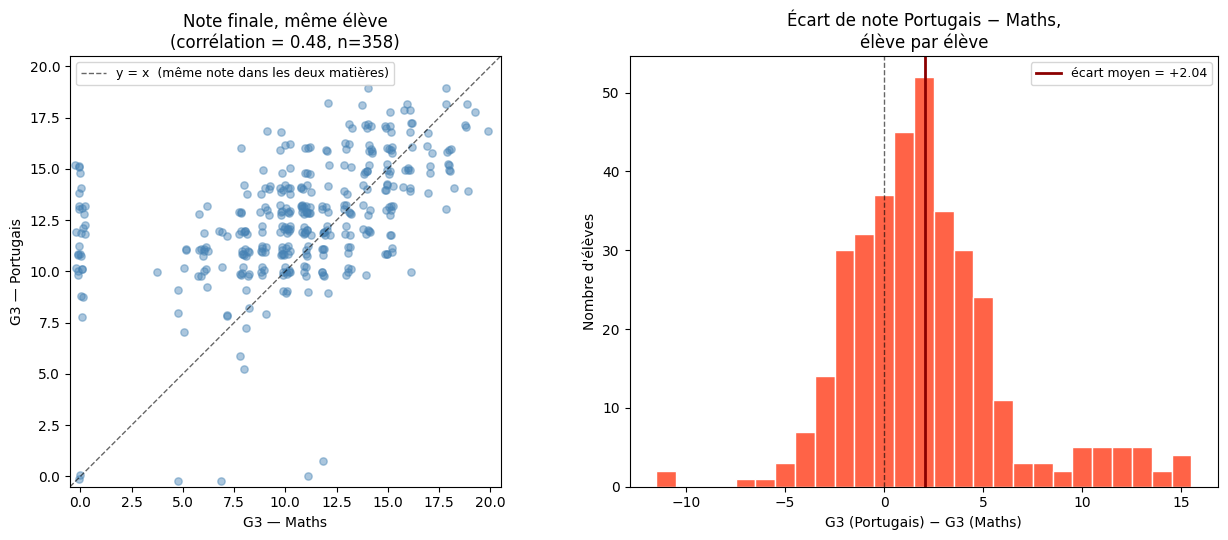

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
jitter = np.random.RandomState(0).uniform(-0.25, 0.25, size=(len(clean), 2))
ax.scatter(clean['G3_mat'] + jitter[:, 0], clean['G3_por'] + jitter[:, 1], alpha=0.45, s=28, color='steelblue')
lims = [-0.5, 20.5]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.6, label='y = x  (même note dans les deux matières)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('G3 — Maths'); ax.set_ylabel('G3 — Portugais')
ax.set_title(f"Note finale, même élève\n(corrélation = {clean['G3_mat'].corr(clean['G3_por']):.2f}, n={len(clean)})")
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')

ax = axes[1]
diff = clean['G3_por'] - clean['G3_mat']
ax.hist(diff, bins=np.arange(diff.min() - 0.5, diff.max() + 1.5, 1), color='tomato', edgecolor='white')
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6)
ax.axvline(diff.mean(), color='darkred', lw=2, label=f'écart moyen = {diff.mean():+.2f}')
ax.set_xlabel('G3 (Portugais) − G3 (Maths)')
ax.set_ylabel("Nombre d'élèves")
ax.set_title("Écart de note Portugais − Maths,\nélève par élève")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Et si on regroupe les élèves selon leur profil dans les *deux* matières ?

Toutes les analyses précédentes regardent une variable à la fois (une note, un comportement). La jointure
permet une chose que ni `student-mat` ni `student-por` pris isolément ne permettent : construire, pour
chaque élève, **un profil qui combine ses deux résultats scolaires** — Maths et Portugais côte à côte —
avec son contexte familial et comportemental (qui, on l'a vu, est rigoureusement le même des deux côtés).

On reprend **exactement la méthode de `acp_kmeans`** : centrage-réduction, ACP, conservation des
composantes à 80% de variance, puis K-means à k=3, 4 et 5, sur les 358 élèves `clean`. La question posée
est nouvelle : **existe-t-il des profils d'élèves « doublement inscrits » qui se distinguent par la façon
dont ils négocient les deux matières** — bons partout, faibles partout, ou bons dans une matière et pas
l'autre ?

In [46]:
from sklearn.cluster import KMeans

# Variables partagées et identiques des deux côtés (cf. section 3) — on prend la version `_mat`,
# rigoureusement égale à la version `_por`
shared_unsuffixed = ['age', 'Medu', 'Fedu']                 # dans la clé de jointure : pas de suffixe
shared_suffixed   = ['traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

# Variables spécifiques au cours suivi : on garde les DEUX versions, c'est précisément ce qu'on veut comparer
subject_specific = ['failures', 'absences', 'G1', 'G2', 'G3']

X_df = pd.DataFrame()
for c in shared_unsuffixed:
    X_df[c] = clean[c]
for c in shared_suffixed:
    X_df[c] = clean[c + '_mat']
for c in subject_specific:
    X_df[c + '_mat'] = clean[c + '_mat']
    X_df[c + '_por'] = clean[c + '_por']

print(f"Matrice de variables : {X_df.shape[0]} élèves × {X_df.shape[1]} variables")
print(f"  — {len(shared_unsuffixed) + len(shared_suffixed)} variables de contexte (identiques Maths/Portugais)")
print(f"  — {len(subject_specific)} variables dédoublées Maths × Portugais "
      f"({', '.join(subject_specific)}) → {len(subject_specific)*2} colonnes")
print()
print("C'est ce dédoublement qui rend cette analyse impossible sans la jointure : dans `student-mat` ou "
      "`student-por` pris séparément, chaque élève n'a qu'UNE série de notes — ici, chacun en a DEUX, "
      "ce qui permet à K-means de voir directement l'écart entre les deux matières comme une dimension du profil.")

Matrice de variables : 358 élèves × 21 variables
  — 11 variables de contexte (identiques Maths/Portugais)
  — 5 variables dédoublées Maths × Portugais (failures, absences, G1, G2, G3) → 10 colonnes

C'est ce dédoublement qui rend cette analyse impossible sans la jointure : dans `student-mat` ou `student-por` pris séparément, chaque élève n'a qu'UNE série de notes — ici, chacun en a DEUX, ce qui permet à K-means de voir directement l'écart entre les deux matières comme une dimension du profil.


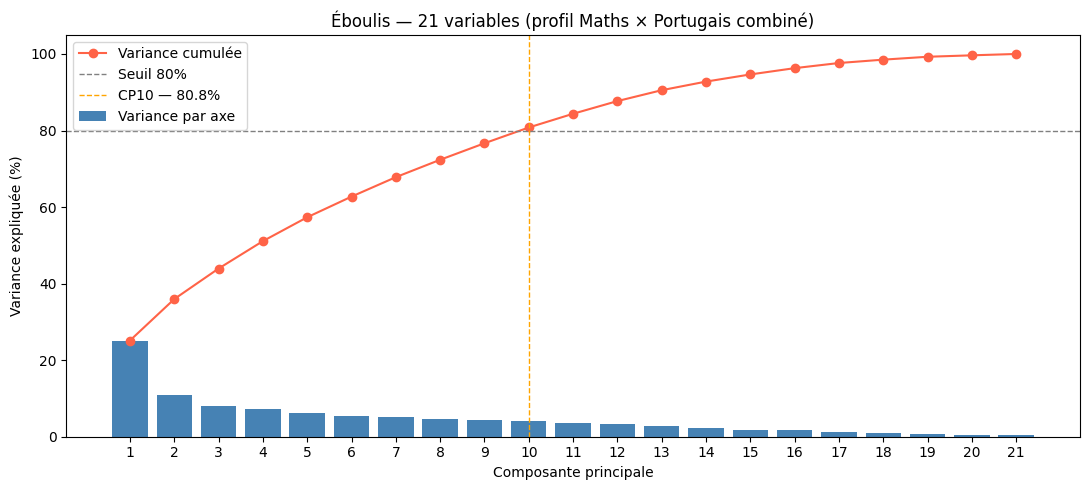

On conserve 10 composantes (80.8% de variance) pour le clustering.


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
N_COMP = int(np.argmax(cum >= 0.80)) + 1

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(1, len(cum)+1), pca_full.explained_variance_ratio_ * 100, color='steelblue', label='Variance par axe')
ax.plot(range(1, len(cum)+1), cum * 100, 'o-', color='tomato', label='Variance cumulée')
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='Seuil 80%')
ax.axvline(N_COMP, color='orange', linestyle='--', linewidth=1, label=f'CP{N_COMP} — {cum[N_COMP-1]*100:.1f}%')
ax.set_xlabel('Composante principale'); ax.set_ylabel('Variance expliquée (%)')
ax.set_title(f'Éboulis — {X_df.shape[1]} variables (profil Maths × Portugais combiné)')
ax.set_xticks(range(1, len(cum)+1))
ax.legend()
plt.tight_layout()
plt.show()

pca9 = PCA(n_components=N_COMP, random_state=42)
X_pca9 = pca9.fit_transform(X_scaled)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print(f"On conserve {N_COMP} composantes ({cum[N_COMP-1]*100:.1f}% de variance) pour le clustering.")

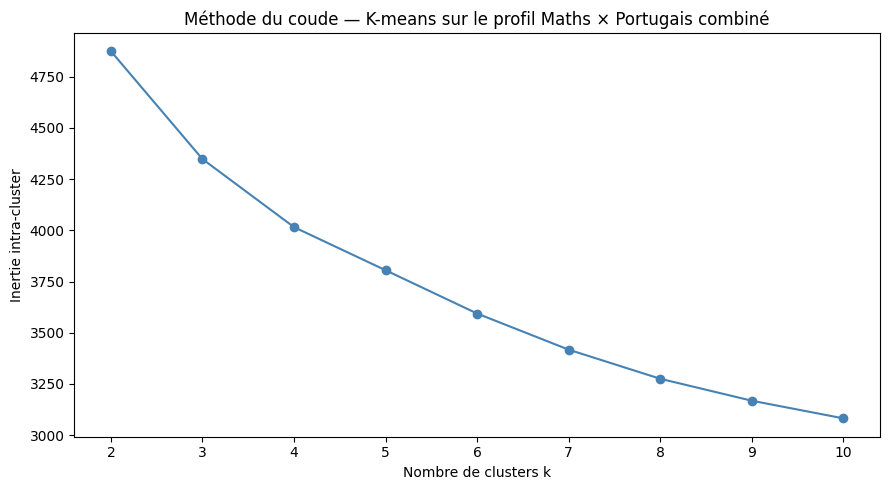

In [48]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_pca9)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertias, 'o-', color='steelblue')
plt.xlabel('Nombre de clusters k'); plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude — K-means sur le profil Maths × Portugais combiné')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

## 6. K-means — k=3, 4, 5

Comme dans `acp_kmeans`, on regarde les trois découpages : k=3 pour les grandes masses, k=4 et k=5 pour
voir comment elles se subdivisent. Le profil affiché met volontairement les notes Maths et Portugais
**côte à côte** (`G3_mat` / `G3_por`, etc.) — c'est précisément cette juxtaposition qui permet de repérer
si un cluster réussit pareil dans les deux matières, ou s'il creuse l'écart.

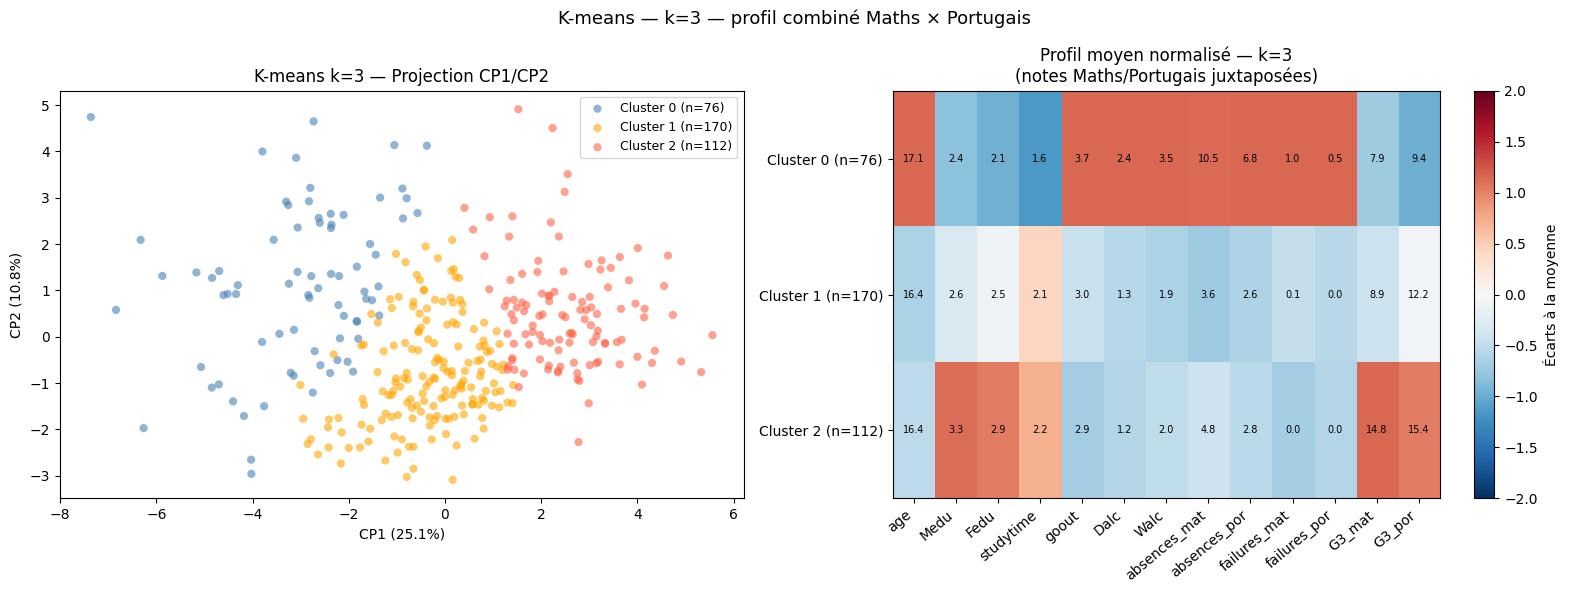

k=3 — écart moyen Maths − Portugais (G3) par cluster :
  Cluster 0 (n= 76) : G3_mat= 7.91  G3_por= 9.43   écart=-1.53   failures_mat=0.97  failures_por=0.49
  Cluster 1 (n=170) : G3_mat= 8.92  G3_por=12.15   écart=-3.24   failures_mat=0.12  failures_por=0.04
  Cluster 2 (n=112) : G3_mat=14.81  G3_por=15.38   écart=-0.56   failures_mat=0.01  failures_por=0.03



In [49]:
PALETTE = ['steelblue', 'orange', 'tomato', 'mediumseagreen', 'purple']
PROFILE_COLS = ['age', 'Medu', 'Fedu', 'studytime', 'goout', 'Dalc', 'Walc', 'absences_mat', 'absences_por',
                'failures_mat', 'failures_por', 'G3_mat', 'G3_por']

def run_kmeans_jointure(k):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for c in range(k):
        mask = labels == c
        axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=PALETTE[c],
                        label=f'Cluster {c} (n={mask.sum()})', alpha=0.6, s=35, edgecolors='none')
    axes[0].set_xlabel(f'CP1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'CP2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title(f'K-means k={k} — Projection CP1/CP2')
    axes[0].legend(fontsize=9)

    df_tmp = X_df.copy()
    df_tmp['cluster'] = labels
    profile = df_tmp.groupby('cluster')[PROFILE_COLS].mean()
    profile_norm = (profile - profile.mean()) / profile.std()

    im = axes[1].imshow(profile_norm.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    axes[1].set_xticks(range(len(PROFILE_COLS))); axes[1].set_xticklabels(PROFILE_COLS, rotation=40, ha='right')
    axes[1].set_yticks(range(k)); axes[1].set_yticklabels([f'Cluster {i} (n={int((labels==i).sum())})' for i in range(k)])
    axes[1].set_title(f'Profil moyen normalisé — k={k}\n(notes Maths/Portugais juxtaposées)')
    plt.colorbar(im, ax=axes[1], label='Écarts à la moyenne')
    for i in range(k):
        for j, col in enumerate(PROFILE_COLS):
            axes[1].text(j, i, f'{profile.values[i,j]:.1f}', ha='center', va='center', fontsize=7)

    plt.suptitle(f'K-means — k={k} — profil combiné Maths × Portugais', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"k={k} — écart moyen Maths − Portugais (G3) par cluster :")
    for c in range(k):
        m = profile.loc[c]
        ecart = m['G3_mat'] - m['G3_por']
        print(f"  Cluster {c} (n={(labels==c).sum():3d}) : G3_mat={m['G3_mat']:5.2f}  G3_por={m['G3_por']:5.2f}"
              f"   écart={ecart:+.2f}   failures_mat={m['failures_mat']:.2f}  failures_por={m['failures_por']:.2f}")
    print()
    return labels

labels3 = run_kmeans_jointure(3)

### k=3 — trois profils de réussite croisée, et un écart Maths-Portugais qui n'est PAS uniforme

C'est le résultat le plus net de cette analyse : **l'écart de notation entre Maths et Portugais, qu'on
avait mesuré en moyenne sur toute la population (≈ −2 points), n'est pas du tout réparti uniformément**
— il est concentré dans un seul des trois groupes :

- **Cluster 2 — « Excellents partout » (n=112)** : `Medu`/`Fedu` les plus élevés, quasiment aucun échec
  (`failures_mat`≈0.01), peu d'absences. Bonnes notes dans les deux matières (G3_mat≈14.8, G3_por≈15.4)
  — **l'écart Maths-Portugais s'efface presque complètement (−0.6)**. Visiblement, le profil qui maîtrise
  une matière maîtrise aussi l'autre : la réussite scolaire, à ce niveau, semble transversale.

- **Cluster 1 — « Moyens, mais nettement mieux en Portugais » (n=170)** : peu d'échecs (`failures_mat`≈0.12),
  peu d'absences, bons résultats en Portugais (G3_por≈12.2) mais nettement plus faibles en Maths
  (G3_mat≈8.9) — **c'est ce groupe qui porte, à lui seul, l'essentiel de l'écart Maths-Portugais observé
  dans la population (−3.2, soit bien plus que la moyenne globale de −2)**. Ce sont des élèves qui
  réussissent dans l'absolu, mais dont la réussite ne se transfère pas symétriquement d'une matière à l'autre.

- **Cluster 0 — « Décrochage généralisé » (n=76)** : le groupe le plus en difficulté sur tous les plans —
  `failures_mat`≈0.97 **et** `failures_por`≈0.49 (les deux nettement supérieurs aux autres groupes),
  absences les plus nombreuses dans les deux matières, consommation d'alcool et sorties les plus élevées,
  parents les moins éduqués. Les notes sont les plus faibles dans les deux matières (G3_mat≈7.9,
  G3_por≈9.4), avec un écart intermédiaire (−1.5).

**L'enseignement principal** : l'écart Maths-Portugais, loin d'être un simple « biais de notation »
appliqué uniformément à toute la population, est un phénomène concentré sur le groupe « moyen ». Les
meilleurs élèves transcendent la matière (ils réussissent dans les deux, presque à égalité) ; les élèves
en difficulté échouent dans les deux (avec, de surcroît, des échecs *spécifiques* à chaque matière —
`failures_mat` et `failures_por` sont tous deux élevés, mais pas identiques) ; et c'est le groupe
intermédiaire qui révèle le plus nettement la différence entre les deux disciplines.

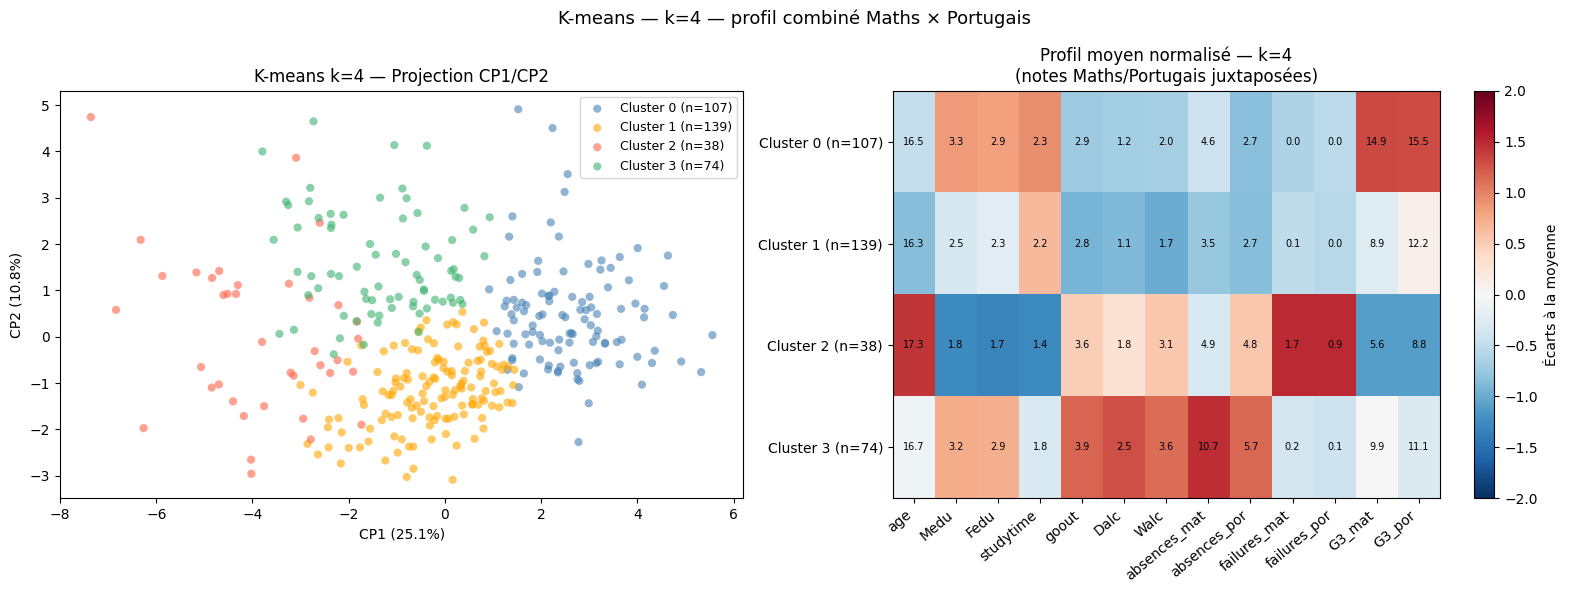

k=4 — écart moyen Maths − Portugais (G3) par cluster :
  Cluster 0 (n=107) : G3_mat=14.88  G3_por=15.50   écart=-0.63   failures_mat=0.01  failures_por=0.03
  Cluster 1 (n=139) : G3_mat= 8.92  G3_por=12.16   écart=-3.24   failures_mat=0.09  failures_por=0.01
  Cluster 2 (n= 38) : G3_mat= 5.61  G3_por= 8.84   écart=-3.24   failures_mat=1.71  failures_por=0.92
  Cluster 3 (n= 74) : G3_mat= 9.88  G3_por=11.08   écart=-1.20   failures_mat=0.22  failures_por=0.08



In [50]:
labels4 = run_kmeans_jointure(4)

### k=4 — le groupe « moyen, mais meilleur en Portugais » se confirme, le décrochage se scinde

Le passage à k=4 affine la photographie sans la contredire :

- **Cluster 0 — « Excellents partout » (n=107)** : quasi identique à l'ancien Cluster 2 (Medu≈3.3, aucun
  échec, G3_mat≈14.9, G3_por≈15.5, écart ≈ −0.6) — ce profil est stable, il ne se subdivise pas.
- **Cluster 1 — « Moyens, et toujours plus à l'aise en Portugais » (n=139)** : reprend très exactement
  l'ancien Cluster 1 — bons résultats en Portugais (G3_por≈12.2), nettement moins bons en Maths
  (G3_mat≈8.9), écart ≈ −3.2, le plus marqué de tous les groupes.
- **Cluster 2 — « Décrochage sévère, surtout en Maths » (n=38)** : un sous-groupe extrait du décrochage
  généralisé — le plus âgé, `failures_mat`≈**1.71** (le plus haut), `failures_por`≈0.92, les notes les plus
  faibles dans les deux matières (G3_mat≈5.6, G3_por≈8.8). Très petit groupe (n=38), à interpréter avec
  prudence, mais il isole un profil de décrochage *concentré sur les Maths plus que sur le Portugais*
  (l'écart d'échecs `failures_mat` − `failures_por` ≈ 0.8 est le plus grand de tous les clusters).
- **Cluster 3 — « Décrochage par absentéisme, surtout en Maths » (n=74)** : un autre visage du décrochage
  — `absences_mat`≈**10.7** (le plus haut, plus du double de `absences_por`≈5.7), mais `failures` modérés
  (≈0.22/0.08). Ce groupe ne se définit pas par l'échec mais par l'absentéisme, et cet absentéisme cible
  nettement plus la classe de Maths que celle de Portugais.

**La nouveauté de k=4** : le grand groupe « décrochage généralisé » de k=3 (n=76) se révèle composite —
il combine en réalité deux profils différents de difficulté scolaire, l'un par échec répété (Cluster 2,
concentré en Maths), l'autre par absentéisme (Cluster 3, également concentré en Maths). Dans les deux cas,
**la difficulté scolaire n'est pas répartie également entre les deux matières — elle pèse plus lourd sur
les Maths**, faisant écho au résultat de la section 4 (31 échecs totaux en Maths contre 5 en Portugais).

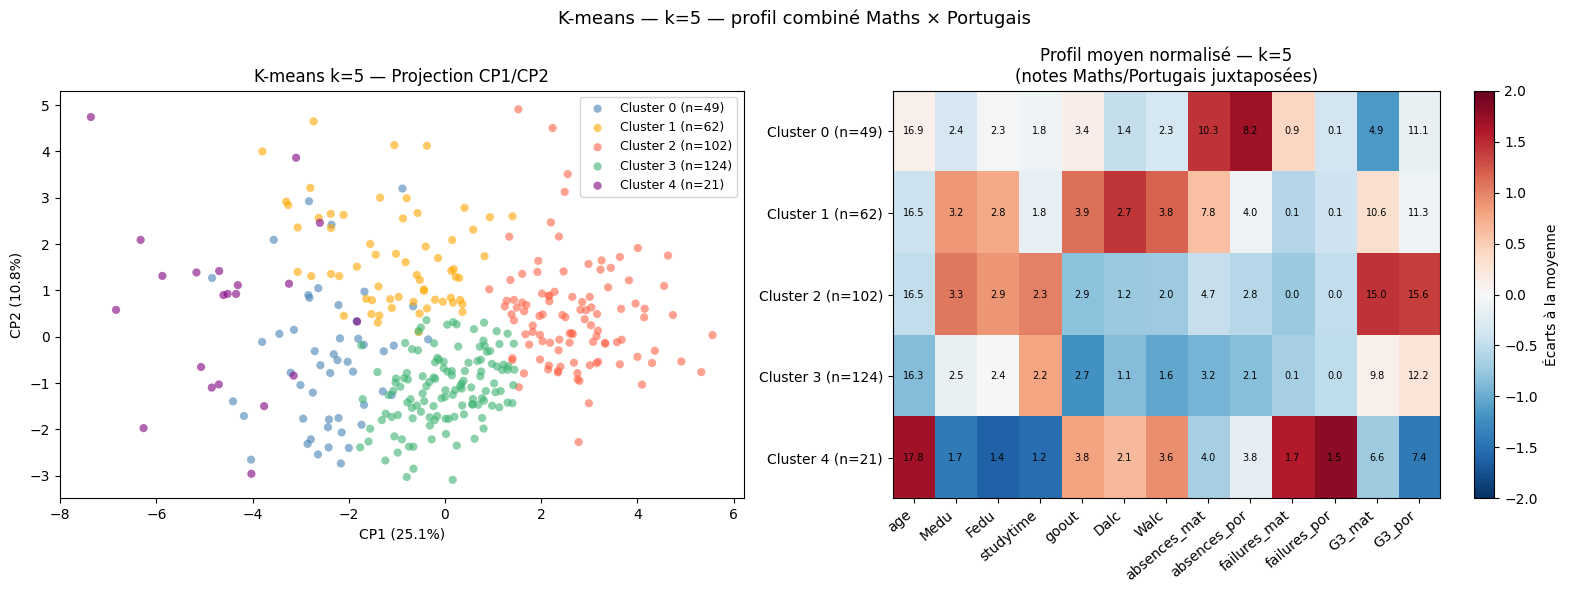

k=5 — écart moyen Maths − Portugais (G3) par cluster :
  Cluster 0 (n= 49) : G3_mat= 4.90  G3_por=11.08   écart=-6.18   failures_mat=0.86  failures_por=0.10
  Cluster 1 (n= 62) : G3_mat=10.63  G3_por=11.27   écart=-0.65   failures_mat=0.13  failures_por=0.08
  Cluster 2 (n=102) : G3_mat=14.98  G3_por=15.58   écart=-0.60   failures_mat=0.01  failures_por=0.03
  Cluster 3 (n=124) : G3_mat= 9.76  G3_por=12.25   écart=-2.49   failures_mat=0.06  failures_por=0.02
  Cluster 4 (n= 21) : G3_mat= 6.62  G3_por= 7.38   écart=-0.76   failures_mat=1.71  failures_por=1.48



In [51]:
labels5 = run_kmeans_jointure(5)

### k=5 — un profil extrême émerge : catastrophique en Maths, simplement faible en Portugais

À k=5, ce n'est pas le haut du spectre qui se distingue le plus, mais un nouveau profil au comportement
inattendu — **le plus grand écart Maths-Portugais de toute l'analyse, et de loin** :

- **Cluster 0 — « Échec ciblé sur les Maths » (n=49)** : `G3_mat`≈**4.9** — la pire moyenne en Maths de
  *toute* cette analyse, tous clusters confondus (pire encore que le « décrochage généralisé » de k=3 à
  7.9, ou le « décrochage sévère » de k=4 à 5.6) — mais `G3_por`≈**11.1**, c'est-à-dire proche de la
  moyenne générale en Portugais (12.6). **Écart = −6.2 points**, environ trois fois l'écart moyen mesuré
  sur l'ensemble de la population (−2.0). `failures_mat`≈0.86 contre `failures_por`≈0.10 : ces élèves ont
  un passif d'échecs concentré sur les Maths, alors que leur dossier en Portugais reste presque normal.
- **Cluster 2 — « Excellents partout » (n=102)** : stable depuis k=3/k=4 (G3_mat≈15.0, G3_por≈15.6,
  écart≈−0.6, `failures`≈0).
- **Cluster 1 — « Convenables et équilibrés » (n=62)** : un profil intermédiaire à l'écart minimal
  (G3_mat≈10.6, G3_por≈11.3, écart≈−0.65) — l'un des rares groupes « moyens » où les deux matières se
  valent.
- **Cluster 3 — « Moyens, mieux en Portugais » (n=124)** : reprend le profil central de k=3/k=4
  (G3_mat≈9.8, G3_por≈12.3, écart≈−2.5).
- **Cluster 4 — « Décrochage sévère et symétrique » (n=21)** : le plus petit groupe, `failures_mat`≈1.71
  **et** `failures_por`≈1.48 — les deux à un niveau extrême et comparable —, avec les pires notes dans
  les deux matières (G3_mat≈6.6, G3_por≈7.4) mais un écart faible (−0.76) : ici, l'échec est massif et
  *symétrique*, contrairement au Cluster 0.

**La fragmentation à k=5 affine donc la lecture d'une façon inattendue** : elle ne confirme pas
l'hypothèse d'un écart « qui se resserre aux extrêmes » — elle révèle au contraire qu'**aux marges du
spectre se cachent les deux situations les plus radicalement opposées** : un échec massif et symétrique
dans les deux matières (Cluster 4, écart quasi nul) *et*, à l'autre bout, un échec spectaculairement
concentré sur une seule matière (Cluster 0, écart de −6.2). Le « décrochage généralisé » identifié à k=3
était donc en réalité un mélange de ces deux profils very different — l'un où la difficulté est un trait
de l'élève (les deux matières sombrent ensemble), l'autre où elle est un trait de la rencontre
élève-matière (une seule matière sombre, l'autre reste dans la norme).

## 8. K-means étendu — on ajoute les variables booléennes et catégorielles

L'analyse précédente ne mobilisait que des variables quantitatives. Mais `acp_kmeans` montre, sur chaque
dataset pris isolément, que les variables booléennes (`internet`, `higher`, `romantic`...) et
catégorielles (`Mjob`, `Fjob`, `reason`...) sont **structurantes** — elles séparent nettement les groupes
« élite héréditaire », « hustlers », « décrochage »... On reprend ici **exactement la même extension de
méthode** : encodage des booléens en 0/1, encodage one-hot (`drop='first'`) des catégorielles, puis
nouvelle ACP et nouveau K-means k=3/4/5 sur cet espace élargi.

La question : est-ce que ces dimensions sociales et institutionnelles **renforcent** la lecture
« écart Maths-Portugais » qui se dégageait du clustering quantitatif, ou est-ce qu'elles la **diluent**
en mettant en avant d'autres lignes de partage (capital social, ambitions, profil familial) ?

Pour le découpage Maths/Portugais, trois cas de figure :
- les variables **identiques des deux côtés** (`schoolsup`, `famsup`, `activities`, `higher`, `romantic`,
  `nursery`, `internet`, `guardian`, et toutes les catégorielles de la clé) sont encodées **une seule fois**
- `paid` est **dédoublée** (`paid_mat` / `paid_por`) — on a vu en section « Simplifier le tableau » que
  c'est la seule variable booléenne à différer significativement (53.9% d'accord seulement) entre les
  deux matières

In [52]:
from sklearn.preprocessing import OneHotEncoder

bool_shared = ['schoolsup', 'famsup', 'activities', 'higher', 'romantic']  # suffixées mais identiques
bool_in_key = ['nursery', 'internet']                                       # dans la clé : pas de suffixe
bool_subject = ['paid']                                                     # diffère selon la matière

cat_in_key      = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason']
cat_shared_dup  = ['guardian']                                              # suffixée mais identique

X_ext = X_df.copy()  # on part du profil quantitatif comparatif déjà construit (21 variables)

for c in bool_shared:
    X_ext[c] = (clean[c + '_mat'] == 'yes').astype(int)
for c in bool_in_key:
    X_ext[c] = (clean[c] == 'yes').astype(int)
for c in bool_subject:
    X_ext[c + '_mat'] = (clean[c + '_mat'] == 'yes').astype(int)
    X_ext[c + '_por'] = (clean[c + '_por'] == 'yes').astype(int)

cat_source = pd.concat([
    clean[cat_in_key].reset_index(drop=True),
    clean[[c + '_mat' for c in cat_shared_dup]].rename(columns=lambda x: x[:-4]).reset_index(drop=True)
], axis=1)
enc = OneHotEncoder(sparse_output=False, drop='first')
cat_enc = pd.DataFrame(enc.fit_transform(cat_source), columns=enc.get_feature_names_out(cat_source.columns))
X_ext = pd.concat([X_ext.reset_index(drop=True), cat_enc], axis=1)

print(f"Matrice étendue : {X_ext.shape[0]} élèves × {X_ext.shape[1]} variables "
      f"(contre {X_df.shape[1]} dans la version quantitative seule)")
print(f"  — {len(bool_shared) + len(bool_in_key)} booléennes partagées + {len(bool_subject)*2} dédoublées (paid)")
print(f"  — {cat_enc.shape[1]} indicatrices issues de l'encodage one-hot de {len(cat_in_key) + len(cat_shared_dup)} variables catégorielles")

Matrice étendue : 358 élèves × 48 variables (contre 21 dans la version quantitative seule)
  — 7 booléennes partagées + 2 dédoublées (paid)
  — 18 indicatrices issues de l'encodage one-hot de 9 variables catégorielles


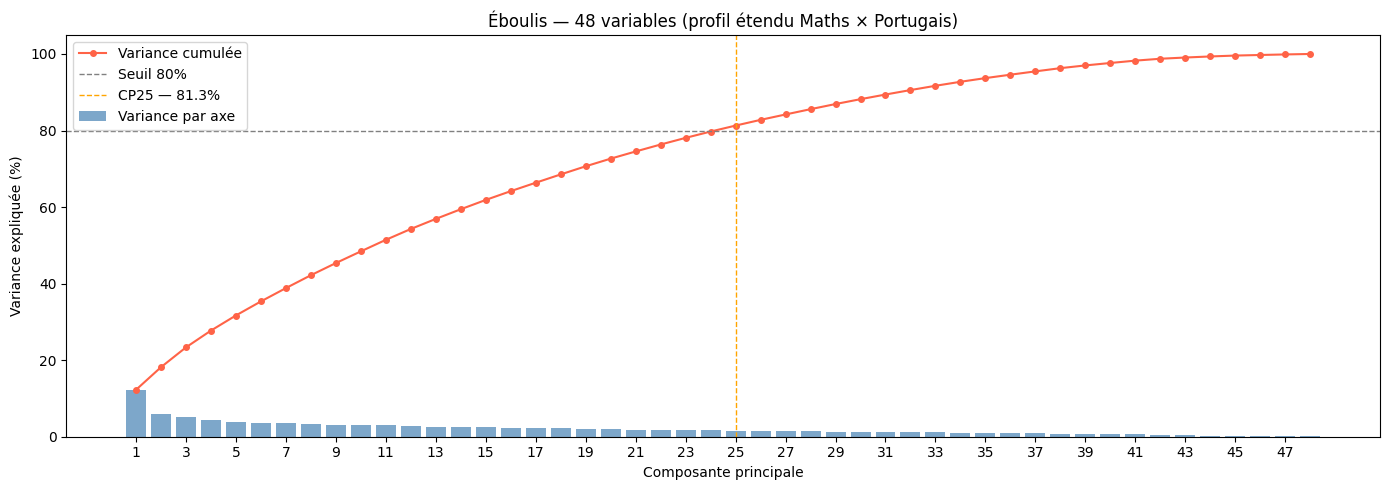

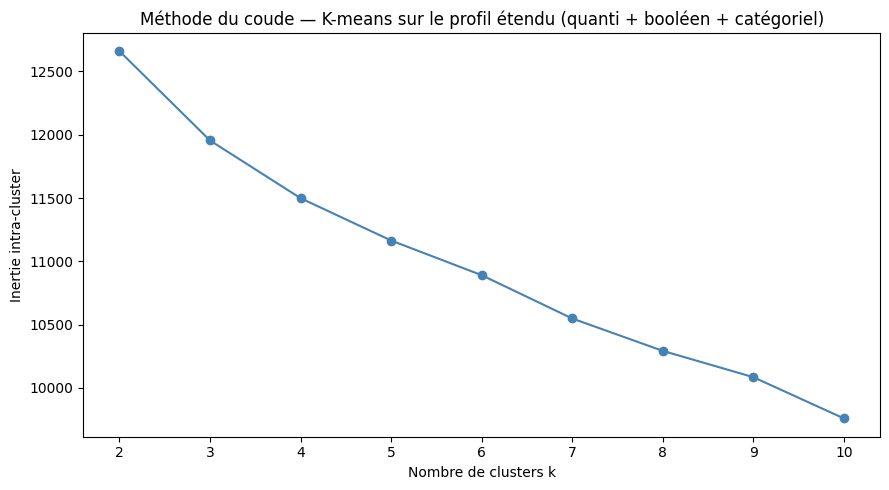

On conserve 25 composantes (81.3% de variance) pour le clustering étendu.


In [53]:
scaler_ext = StandardScaler()
X_scaled_ext = scaler_ext.fit_transform(X_ext)

pca_full_ext = PCA(random_state=42)
pca_full_ext.fit(X_scaled_ext)
cum_ext = np.cumsum(pca_full_ext.explained_variance_ratio_)
N_COMP_EXT = int(np.argmax(cum_ext >= 0.80)) + 1

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(1, len(cum_ext)+1), pca_full_ext.explained_variance_ratio_ * 100, color='steelblue', alpha=0.7, label='Variance par axe')
ax.plot(range(1, len(cum_ext)+1), cum_ext * 100, 'o-', color='tomato', markersize=4, label='Variance cumulée')
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='Seuil 80%')
ax.axvline(N_COMP_EXT, color='orange', linestyle='--', linewidth=1, label=f'CP{N_COMP_EXT} — {cum_ext[N_COMP_EXT-1]*100:.1f}%')
ax.set_xlabel('Composante principale'); ax.set_ylabel('Variance expliquée (%)')
ax.set_title(f'Éboulis — {X_ext.shape[1]} variables (profil étendu Maths × Portugais)')
ax.set_xticks(range(1, len(cum_ext)+1, 2))
ax.legend()
plt.tight_layout()
plt.show()

pca9_ext = PCA(n_components=N_COMP_EXT, random_state=42)
X_pca9_ext = pca9_ext.fit_transform(X_scaled_ext)
pca2_ext = PCA(n_components=2, random_state=42)
X_pca2_ext = pca2_ext.fit_transform(X_scaled_ext)

inertias_ext = []
for k in range(2, 11):
    inertias_ext.append(KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_pca9_ext).inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertias_ext, 'o-', color='steelblue')
plt.xlabel('Nombre de clusters k'); plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude — K-means sur le profil étendu (quanti + booléen + catégoriel)')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

print(f"On conserve {N_COMP_EXT} composantes ({cum_ext[N_COMP_EXT-1]*100:.1f}% de variance) pour le clustering étendu.")

## 9. K-means étendu — k=3, 4, 5

Même lecture que précédemment : un scatter CP1/CP2, et un profil normalisé portant cette fois sur un
sous-ensemble lisible de variables-clés — capital parental, comportement, échecs/absences/notes
(juxtaposés Maths/Portugais), et quelques booléennes structurantes (`higher`, `internet`, `romantic`,
`paid`).

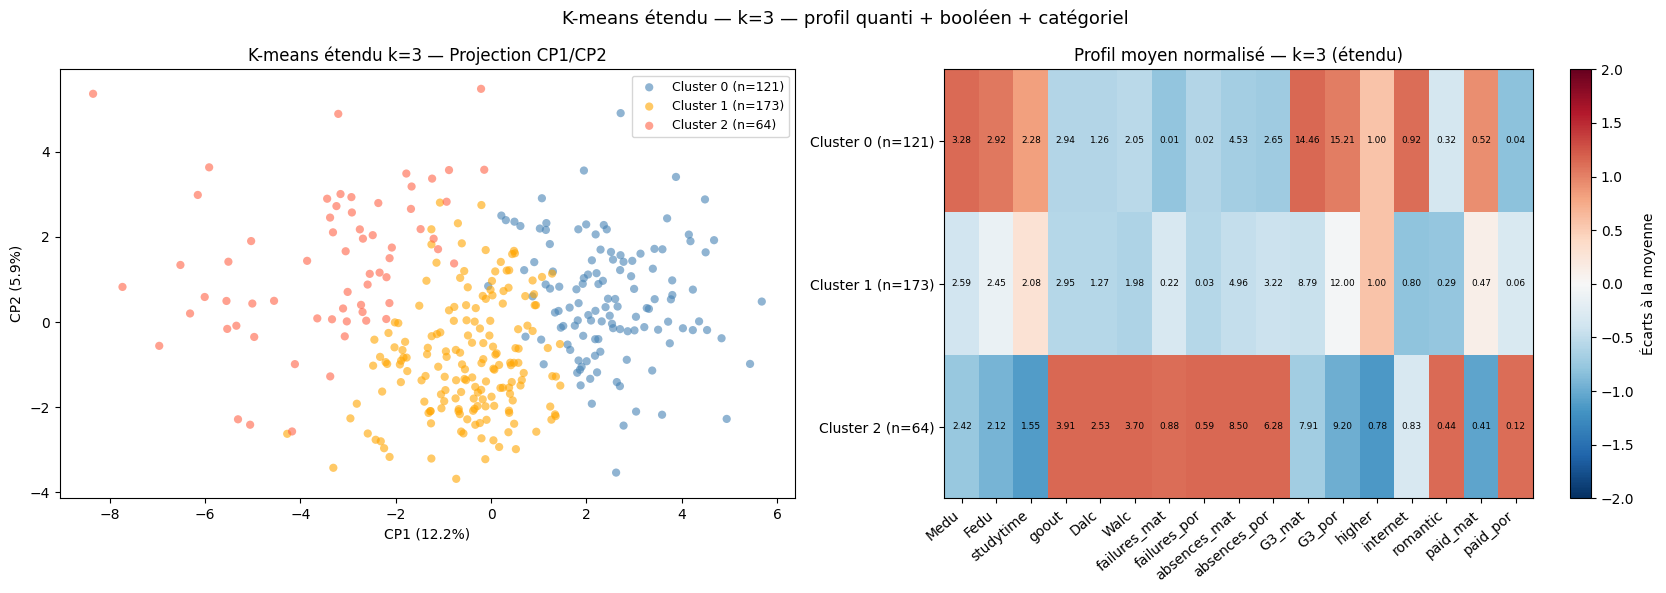

k=3 — écart Maths − Portugais (G3) et profil social par cluster :
  Cluster 0 (n=121) : G3_mat=14.46  G3_por=15.21  écart=-0.74   Medu=3.28  higher=1.00  internet=0.92  failures_mat=0.01  failures_por=0.02
  Cluster 1 (n=173) : G3_mat= 8.79  G3_por=12.00  écart=-3.21   Medu=2.59  higher=1.00  internet=0.80  failures_mat=0.22  failures_por=0.03
  Cluster 2 (n= 64) : G3_mat= 7.91  G3_por= 9.20  écart=-1.30   Medu=2.42  higher=0.78  internet=0.83  failures_mat=0.88  failures_por=0.59



In [54]:
PROFILE_COLS_EXT = ['Medu', 'Fedu', 'studytime', 'goout', 'Dalc', 'Walc',
                    'failures_mat', 'failures_por', 'absences_mat', 'absences_por',
                    'G3_mat', 'G3_por', 'higher', 'internet', 'romantic', 'paid_mat', 'paid_por']

def run_kmeans_extended(k):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca9_ext)

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    for c in range(k):
        mask = labels == c
        axes[0].scatter(X_pca2_ext[mask, 0], X_pca2_ext[mask, 1], c=PALETTE[c],
                        label=f'Cluster {c} (n={mask.sum()})', alpha=0.6, s=35, edgecolors='none')
    axes[0].set_xlabel(f'CP1 ({pca2_ext.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'CP2 ({pca2_ext.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title(f'K-means étendu k={k} — Projection CP1/CP2')
    axes[0].legend(fontsize=9)

    df_tmp = X_ext.copy()
    df_tmp['cluster'] = labels
    profile = df_tmp.groupby('cluster')[PROFILE_COLS_EXT].mean()
    profile_norm = (profile - profile.mean()) / profile.std()

    im = axes[1].imshow(profile_norm.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    axes[1].set_xticks(range(len(PROFILE_COLS_EXT))); axes[1].set_xticklabels(PROFILE_COLS_EXT, rotation=40, ha='right')
    axes[1].set_yticks(range(k)); axes[1].set_yticklabels([f'Cluster {i} (n={int((labels==i).sum())})' for i in range(k)])
    axes[1].set_title(f'Profil moyen normalisé — k={k} (étendu)')
    plt.colorbar(im, ax=axes[1], label='Écarts à la moyenne')
    for i in range(k):
        for j, col in enumerate(PROFILE_COLS_EXT):
            axes[1].text(j, i, f'{profile.values[i,j]:.2f}', ha='center', va='center', fontsize=6.5)

    plt.suptitle(f'K-means étendu — k={k} — profil quanti + booléen + catégoriel', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"k={k} — écart Maths − Portugais (G3) et profil social par cluster :")
    for c in range(k):
        m = profile.loc[c]
        ecart = m['G3_mat'] - m['G3_por']
        print(f"  Cluster {c} (n={(labels==c).sum():3d}) : G3_mat={m['G3_mat']:5.2f}  G3_por={m['G3_por']:5.2f}"
              f"  écart={ecart:+.2f}   Medu={m['Medu']:.2f}  higher={m['higher']:.2f}  "
              f"internet={m['internet']:.2f}  failures_mat={m['failures_mat']:.2f}  failures_por={m['failures_por']:.2f}")
    print()
    return labels

labels3_ext = run_kmeans_extended(3)

### k=3 (étendu) — la même tripartition refait surface, avec un profil social plus net

On retrouve, presque trait pour trait, la tripartition de la section 6 — ce qui est en soi un résultat
rassurant : l'ajout des variables sociales ne brouille pas la lecture, il **la précise**.

- **Cluster 0 — « Excellents partout, capital élevé » (n=121)** : `Medu`≈3.28, `Fedu`≈2.92,
  `failures_mat`≈0.01, `failures_por`≈0.02, `higher`=1.00, `internet`=0.92 — bonnes notes dans les deux
  matières (G3_mat≈14.5, G3_por≈15.2), écart minimal (−0.75).
- **Cluster 1 — « Moyens, mais nettement mieux en Portugais » (n=173)** : le plus grand groupe, capital
  parental modéré (`Medu`≈2.59), peu d'échecs, `higher`=1.00 — mais l'écart Maths-Portugais est ici le
  plus marqué de tous (G3_mat≈8.8 vs G3_por≈12.0, **écart = −3.21**, le même phénomène déjà identifié en
  section 6).
- **Cluster 2 — « Festif et en difficulté » (n=64)** : `Dalc`≈2.53, `Walc`≈3.70, `goout`≈3.91 — les plus
  hauts de tous les groupes —, `failures_mat`≈0.88 et `failures_por`≈0.59, `higher`=**0.78** (le seul
  groupe sous les 90%) : le profil social vient ici nettement *expliquer* la difficulté scolaire plutôt
  que la simple matière (écart −1.29, intermédiaire).

**Ce que les variables sociales ajoutent** : à k=3 quantitatif, le groupe en difficulté se définissait
surtout par ses notes et ses échecs ; ici, il se définit *en plus* par un comportement (sorties, alcool)
et une ambition réduite (`higher`=0.78) — la difficulté scolaire s'inscrit dans un mode de vie plus large,
pas seulement dans une série de mauvaises notes.

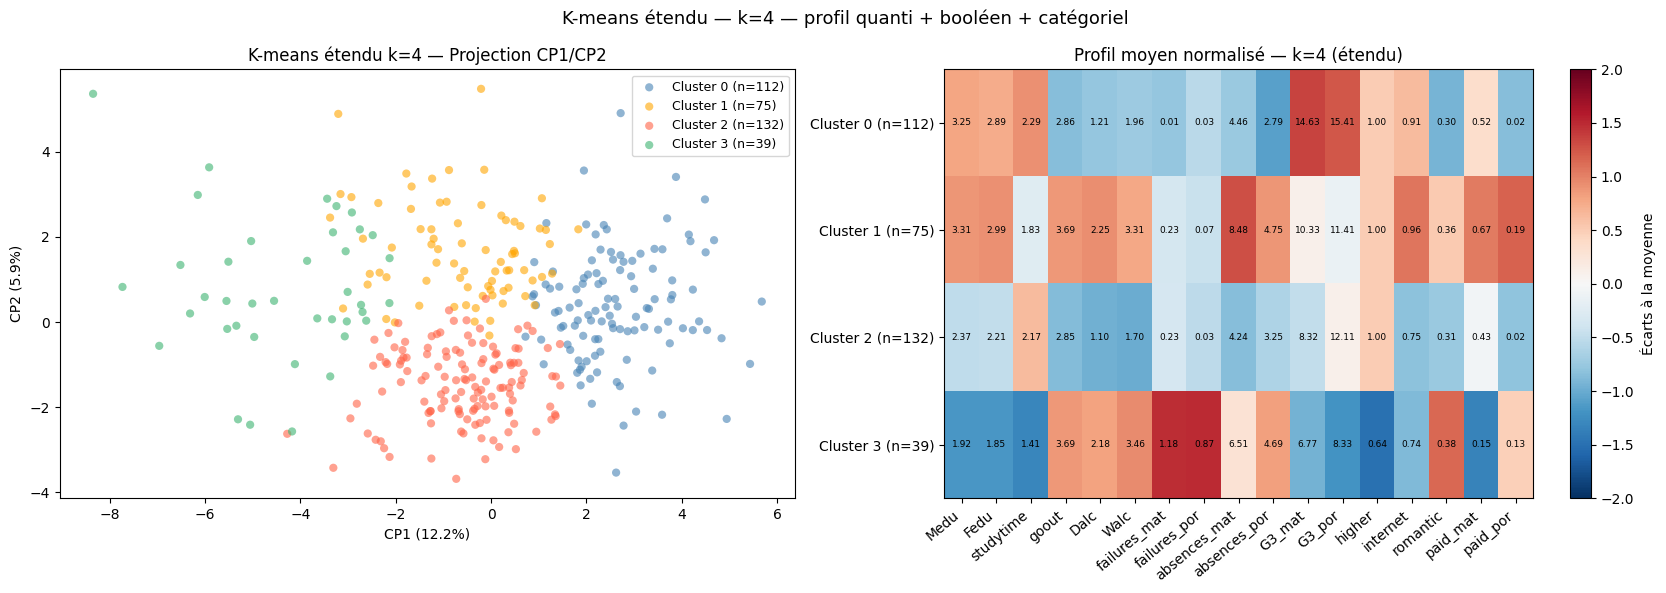

k=4 — écart Maths − Portugais (G3) et profil social par cluster :
  Cluster 0 (n=112) : G3_mat=14.63  G3_por=15.41  écart=-0.78   Medu=3.25  higher=1.00  internet=0.91  failures_mat=0.01  failures_por=0.03
  Cluster 1 (n= 75) : G3_mat=10.33  G3_por=11.41  écart=-1.08   Medu=3.31  higher=1.00  internet=0.96  failures_mat=0.23  failures_por=0.07
  Cluster 2 (n=132) : G3_mat= 8.32  G3_por=12.11  écart=-3.79   Medu=2.37  higher=1.00  internet=0.75  failures_mat=0.23  failures_por=0.03
  Cluster 3 (n= 39) : G3_mat= 6.77  G3_por= 8.33  écart=-1.56   Medu=1.92  higher=0.64  internet=0.74  failures_mat=1.18  failures_por=0.87



In [55]:
labels4_ext = run_kmeans_extended(4)

### k=4 (étendu) — l'écart Maths-Portugais atteint son maximum dans un groupe « capital modeste, mais posé »

Le passage à k=4 fait émerger une lecture plus fine — et un record :

- **Cluster 0 — « Excellents, capital élevé » (n=112)** : stable (Medu≈3.25, écart −0.78, `failures`≈0).
- **Cluster 1 — « Festifs mais portés par l'ambition » (n=75)** : `Dalc`≈2.25, `Walc`≈3.31 — comportement
  festif marqué — mais `higher`=1.00 et de bons résultats malgré tout (G3_mat≈10.3, G3_por≈11.4, écart
  −1.08) : contrairement au cluster festif de k=3, celui-ci ne décroche pas, il garde un cap.
- **Cluster 2 — « Calmes, capital modeste, mais l'écart Maths-Portugais le plus extrême de toute
  l'analyse » (n=132)** : `Dalc`≈1.10 et `Walc`≈1.70 — les plus bas de tous les clusters, comportement
  posé — `failures`≈0.23/0.03, `higher`=1.00. Et pourtant : G3_mat≈8.32 contre G3_por≈12.11, soit un
  **écart de −3.79**, le plus grand jamais observé dans cette analyse étendue. Ce sont des élèves
  sérieux, sans difficulté de comportement ni d'ambition, mais dont la rencontre avec les Maths se passe
  nettement moins bien qu'avec le Portugais.
- **Cluster 3 — « Décrochage social et scolaire » (n=39)** : `Medu`≈1.92 (le plus bas), `failures_mat`≈1.18,
  `failures_por`≈0.87, `higher`=**0.64** (le plus bas) — le profil de rupture le plus complet, scolaire et
  social à la fois (G3_mat≈6.8, G3_por≈8.3, écart −1.56).

**Le résultat-clé** : le plus grand écart Maths-Portugais de toute l'analyse étendue (−3.79, presque le
double de la moyenne de population) se loge précisément dans le groupe au profil social le **plus neutre,
le plus posé, le moins problématique** — ni festif, ni en échec, ni démotivé. C'est la confirmation la
plus nette que l'écart entre les deux matières n'est **pas** un sous-produit du profil social ou
comportemental de l'élève : c'est un phénomène qui lui est largement orthogonal, spécifique à la
rencontre entre l'élève et la discipline.

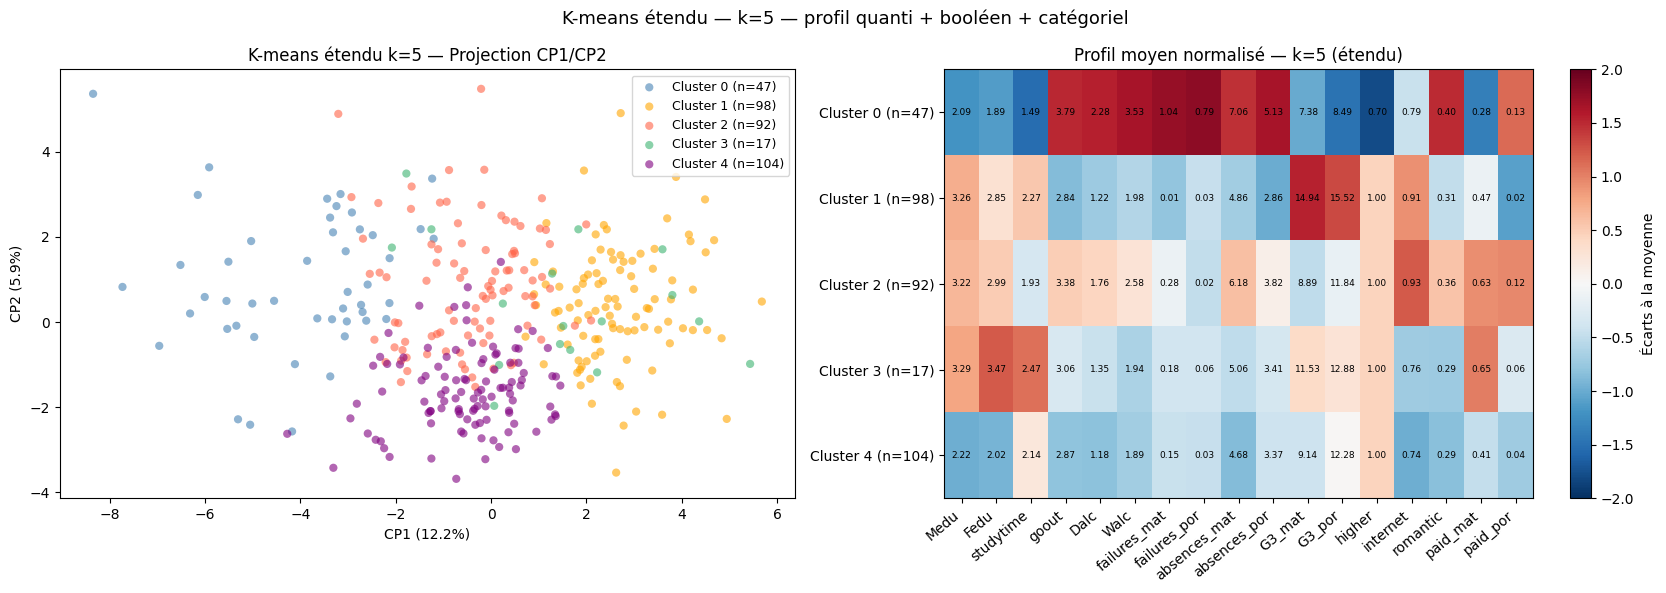

k=5 — écart Maths − Portugais (G3) et profil social par cluster :
  Cluster 0 (n= 47) : G3_mat= 7.38  G3_por= 8.49  écart=-1.11   Medu=2.09  higher=0.70  internet=0.79  failures_mat=1.04  failures_por=0.79
  Cluster 1 (n= 98) : G3_mat=14.94  G3_por=15.52  écart=-0.58   Medu=3.26  higher=1.00  internet=0.91  failures_mat=0.01  failures_por=0.03
  Cluster 2 (n= 92) : G3_mat= 8.89  G3_por=11.84  écart=-2.95   Medu=3.22  higher=1.00  internet=0.93  failures_mat=0.28  failures_por=0.02
  Cluster 3 (n= 17) : G3_mat=11.53  G3_por=12.88  écart=-1.35   Medu=3.29  higher=1.00  internet=0.76  failures_mat=0.18  failures_por=0.06
  Cluster 4 (n=104) : G3_mat= 9.14  G3_por=12.28  écart=-3.13   Medu=2.22  higher=1.00  internet=0.74  failures_mat=0.15  failures_por=0.03



In [56]:
labels5_ext = run_kmeans_extended(5)

### k=5 (étendu) — le constat se maintient, affiné mais pas contredit

À k=5, les groupes se redécoupent mais le message ne change pas :

- **Cluster 1 — « Excellents, capital élevé » (n=98)** : profil stable (G3_mat≈14.9, G3_por≈15.5, écart
  ≈ −0.58, `failures`≈0).
- **Cluster 0 — « Décrochage concentré sur les Maths » (n=47)** : `failures_mat`≈1.04, `failures_por`≈0.79,
  `Walc`≈3.53 (le plus festif), `higher`=0.70 — notes basses dans les deux matières (G3_mat≈7.4,
  G3_por≈8.5) mais un écart modeste (−1.11) : ici la difficulté est largement partagée entre les deux
  matières.
- **Cluster 3 — « Petit groupe à fort capital parental » (n=17)** : `Medu`≈3.29, `Fedu`≈3.47 (les plus
  hauts de l'analyse étendue), bons résultats (G3_mat≈11.5, G3_por≈12.9, écart −1.35) — groupe trop petit
  pour conclure, mais cohérent avec le profil « élite héréditaire » identifié dans `acp_kmeans`.
- **Clusters 2 et 4 — les deux versions du « grand écart »** : deux variantes du profil « calme, capital
  modeste, bien plus à l'aise en Portugais », l'un un peu plus en difficulté globale (Cluster 2, n=92,
  G3_mat≈8.9, G3_por≈11.8, écart −2.95), l'autre un peu meilleur (Cluster 4, n=104, G3_mat≈9.1,
  G3_por≈12.3, écart −3.13). Ensemble, ils représentent **plus de la moitié de la population (n=196,
  55%)** — et tous deux affichent un écart Maths-Portugais nettement supérieur à la moyenne de population
  (−2.0), sans pour autant présenter de profil social ou comportemental remarquable.

**La fragmentation à k=5 ne fait que confirmer, en la subdivisant, l'observation de k=4** : le « grand
écart » n'est pas un accident statistique d'un seul cluster — c'est un phénomène large, stable, qui
concerne la majorité de la population « ordinaire » (ni en échec, ni en excellence), et qui résiste
totalement à l'ajout de dimensions sociales et comportementales.

## 10. Comparaison : clustering quantitatif seul vs étendu

Les deux lectures se ressemblent-elles vraiment, ou est-ce une impression ? L'indice de Rand ajusté (ARI)
permet de le mesurer objectivement — il compare deux partitions indépendamment de la numérotation des
clusters (0 = partitions indépendantes, 1 = identiques).

In [57]:
from sklearn.metrics import adjusted_rand_score

print("Similarité entre le clustering quantitatif seul (section 6) et le clustering étendu (section 9) :\n")
for k, l_old, l_new in [(3, labels3, labels3_ext), (4, labels4, labels4_ext), (5, labels5, labels5_ext)]:
    ari = adjusted_rand_score(l_old, l_new)
    print(f"  k={k} : ARI = {ari:.3f}")
print()
print("(0 = partitions indépendantes, 1 = identiques)")

Similarité entre le clustering quantitatif seul (section 6) et le clustering étendu (section 9) :

  k=3 : ARI = 0.689
  k=4 : ARI = 0.648
  k=5 : ARI = 0.438

(0 = partitions indépendantes, 1 = identiques)


**L'accord est fort sans être total** (ARI ≈ 0.44 à 0.69, décroissant avec k — la fragmentation amplifie
mécaniquement les différences de détail). Les variables sociales et comportementales **réorganisent les
détails** des groupes — qui exactement appartient à quel sous-groupe — mais elles ne renversent à aucun
moment le verdict central : dans les deux lectures, on retrouve la même opposition entre un groupe
d'excellence transversale, un groupe en difficulté généralisée, et — surtout — un grand groupe
intermédiaire où l'écart Maths-Portugais culmine. Ce dernier reste, dans les deux cas, **le trait le plus
saillant de l'analyse**, et son ampleur grandit même légèrement dans la lecture étendue (de −3.24 à
−3.79 au maximum).

**Conclusion de cette extension** : ajouter le contexte social et institutionnel ne dilue pas le signal
Maths-Portugais — au contraire, cela permet de l'isoler plus nettement de tout ce qui *pourrait* sembler
l'expliquer (comportement festif, capital parental, ambition). Le groupe qui porte le plus grand écart
n'est ni le plus favorisé, ni le plus défavorisé, ni le plus festif, ni le plus posé : c'est, tout
simplement, un grand pan « ordinaire » de la population pour qui les deux matières se vivent de façon
fondamentalement différente. C'est la preuve la plus solide, dans tout ce notebook, que la performance
scolaire n'est décidément pas réductible à un profil — elle se joue, pour une part substantielle des
élèves, dans la rencontre elle-même.

## 7. Ce que cette analyse ajoute à la conclusion générale

Cette section confirme, par une voie totalement différente (un clustering non supervisé sur un espace de
variables impossible à construire sans la jointure), le message central de ce notebook — **la performance
scolaire n'est pas une propriété stable de l'élève, transposable d'une matière à l'autre, mais le produit
d'une rencontre entre un profil et un contexte disciplinaire.** Et elle va plus loin : elle montre que
cette rencontre peut tourner de deux façons radicalement différentes, y compris chez les élèves les plus
en difficulté.

Le clustering distingue nettement, parmi les profils en échec, deux logiques opposées : un **échec
symétrique** (Cluster 4 du k=5, n=21 — les deux matières sombrent ensemble, `failures_mat`≈`failures_por`,
écart quasi nul) et un **échec spécifique à une matière** (Cluster 0 du k=5, n=49 — `G3_mat`≈4.9, la pire
moyenne en Maths de toute l'analyse, contre `G3_por`≈11.1, proche de la moyenne générale ; écart de −6.2,
le plus grand mesuré). Le premier profil dit que la difficulté est **un trait de l'élève** — il échoue
partout, indépendamment du contexte. Le second dit qu'elle est **un trait de la rencontre** — un même
élève peut être en situation de décrochage total dans une matière et tout à fait dans la norme dans
l'autre. Sans la jointure, ces deux populations seraient indiscernables : `student-mat` verrait deux
groupes d'élèves en échec aux profils sociodémographiques proches, sans pouvoir établir si l'un d'eux
réussit très bien à côté, en Portugais.

C'est une mise en garde méthodologique pour tout le reste du projet : les modèles construits sur un seul
des deux fichiers (`apprentissage_reussite`, les clusters K-means par matière...) attribuent
implicitement la réussite ou l'échec au *profil* de l'élève. Cette section montre qu'une partie non
négligeable de ce qu'ils mesurent est en réalité spécifique à la matière — une nuance qu'aucune des deux
bases de données prise séparément n'aurait pu révéler.

## 11. Comparer les clusterings mat, por et mat-por sur les 358 élèves communs

Les clusterings de `student-mat` et `student-por` (reproduits ci-dessous avec les **42 variables** d'`acp_kmeans`)
ont été construits sur des populations distinctes — 395 et 649 élèves. Maintenant qu'on dispose des
358 élèves présents dans les deux fichiers, on peut se demander : **dans quelle mesure les trois
K-means (mat, por, mat-por) « voient-ils » les mêmes groupes, alors qu'ils n'ont pas eu accès
aux mêmes informations** ?

Les matrices ci-dessous répondent à deux questions complémentaires, pour k = 3, 4 et 5 :
- **Référence mat** : un élève classé dans le cluster `i` par K-means mat, dans quel cluster mat-por
  atterrit-il ? (lecture par ligne, normalisée en %)
- **Référence por** : idem depuis K-means por

L'Adjusted Rand Index (ARI) synthétise l'accord global en une seule valeur (0 = indépendants,
1 = identiques). Les labels sont réordonnés par matching optimal pour maximiser la lisibilité de
la diagonale.

In [60]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment

NUM_COLS42  = ['age','Medu','Fedu','traveltime','studytime','failures','famrel','freetime',
               'goout','Dalc','Walc','health','absences','G1','G2','G3']
BOOL_COLS42 = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
CAT_COLS42  = ['school','sex','address','famsize','Pstatus','Mjob','Fjob','reason','guardian']

def encode42(df):
    bool_df = df[BOOL_COLS42].apply(lambda c: (c == 'yes').astype(int))
    enc = OneHotEncoder(sparse_output=False, drop='first')
    cat_enc = pd.DataFrame(enc.fit_transform(df[CAT_COLS42]),
                           columns=enc.get_feature_names_out(CAT_COLS42))
    return pd.concat([df[NUM_COLS42].reset_index(drop=True),
                      bool_df.reset_index(drop=True),
                      cat_enc.reset_index(drop=True)], axis=1)

def fit_kmeans_42(X_raw, k_list):
    Xs = StandardScaler().fit_transform(X_raw)
    n80 = int(np.argmax(np.cumsum(PCA().fit(Xs).explained_variance_ratio_) >= 0.80)) + 1
    Xr = PCA(n_components=n80, random_state=42).fit_transform(Xs)
    print(f"  PCA : {n80} composantes, {Xr.shape[0]} individus")
    return {k: KMeans(n_clusters=k, n_init=50, random_state=42).fit_predict(Xr) for k in k_list}

# Jointure avec tracking des indices originaux
mat_idx = student_mat.copy(); mat_idx['_im'] = np.arange(len(student_mat))
por_idx = student_por.copy(); por_idx['_ip'] = np.arange(len(student_por))
merged_idx = pd.merge(mat_idx, por_idx, on=JOIN_COLS, suffixes=('_mat', '_por'))
sizes_idx  = merged_idx.groupby(JOIN_COLS).size()
ck_idx = set(map(tuple, sizes_idx[sizes_idx==1].index.to_frame(index=False).values.tolist()))
is_ck  = merged_idx[JOIN_COLS].apply(tuple, axis=1).isin(ck_idx)
clean_idx = merged_idx[is_ck].reset_index(drop=True)
im = clean_idx['_im'].values
ip = clean_idx['_ip'].values

K_LIST = [3, 4, 5]

print("--- K-means MAT (42 vars) ---")
lbl_mat_all = fit_kmeans_42(encode42(student_mat), K_LIST)
lbl_mat = {k: lbl_mat_all[k][im] for k in K_LIST}

print("--- K-means POR (42 vars) ---")
lbl_por_all = fit_kmeans_42(encode42(student_por), K_LIST)
lbl_por = {k: lbl_por_all[k][ip] for k in K_LIST}

lbl_jnt = {3: labels3_ext, 4: labels4_ext, 5: labels5_ext}

print("\nARI entre les trois clusterings (sur les 358 eleves communs) :")
print(f"{'k':>3} | {'mat vs mat-por':>16} | {'por vs mat-por':>16} | {'mat vs por':>12}")
for k in K_LIST:
    a1 = adjusted_rand_score(lbl_mat[k], lbl_jnt[k])
    a2 = adjusted_rand_score(lbl_por[k], lbl_jnt[k])
    a3 = adjusted_rand_score(lbl_mat[k], lbl_por[k])
    print(f"  k={k} | {a1:16.3f} | {a2:16.3f} | {a3:12.3f}")


--- K-means MAT (42 vars) ---
  PCA : 23 composantes, 395 individus
--- K-means POR (42 vars) ---
  PCA : 24 composantes, 649 individus

ARI entre les trois clusterings (sur les 358 eleves communs) :
  k |   mat vs mat-por |   por vs mat-por |   mat vs por
  k=3 |            0.300 |            0.285 |        0.620
  k=4 |            0.347 |            0.241 |        0.392
  k=5 |            0.324 |            0.331 |        0.702


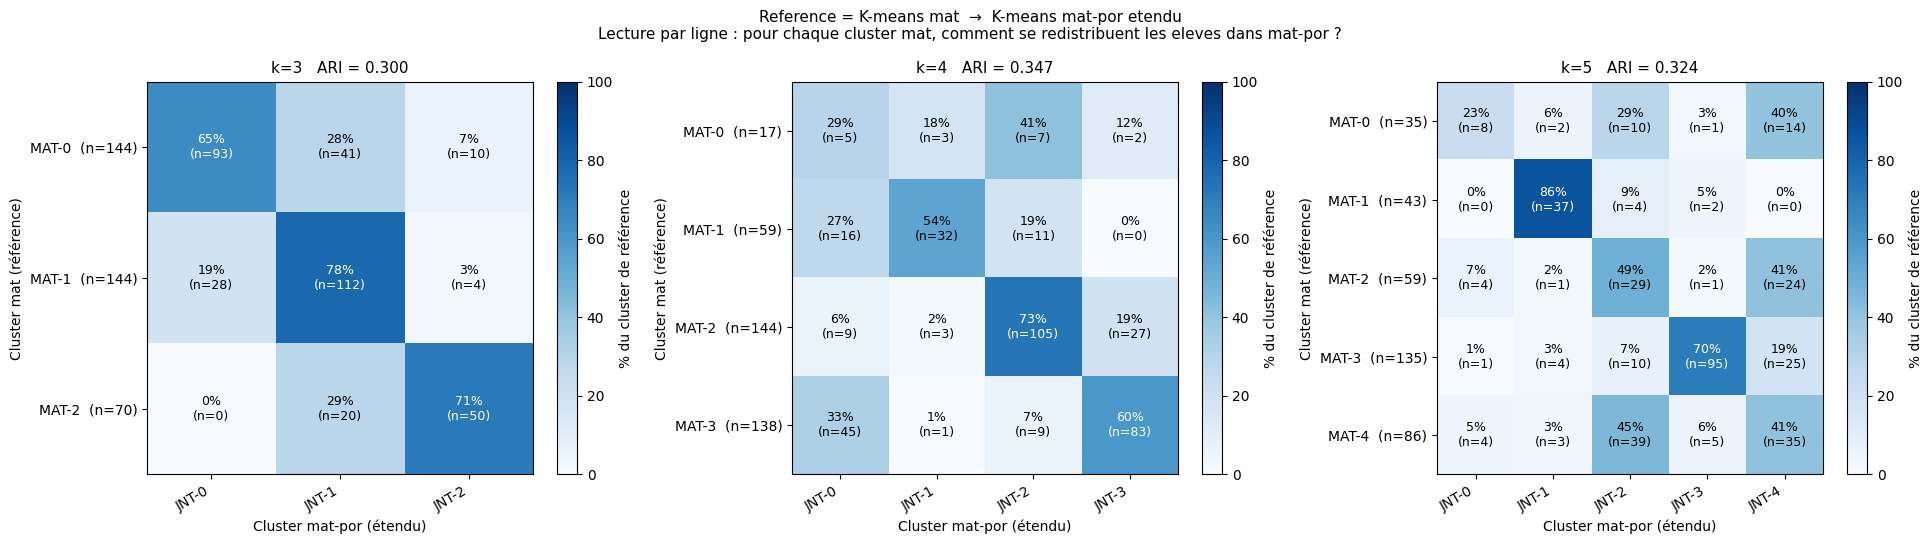

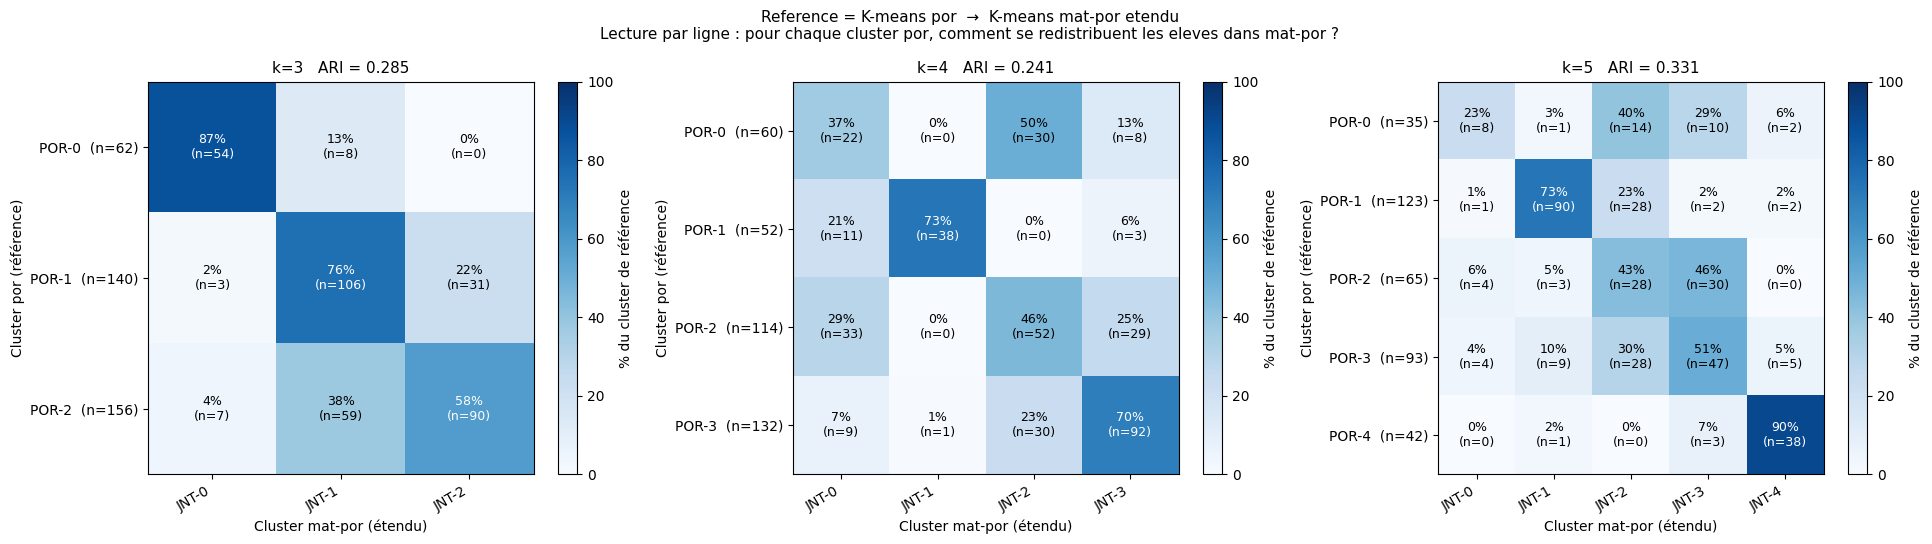

In [61]:
def best_permutation(ref_labels, other_labels, k):
    ct = pd.crosstab(ref_labels, other_labels).values
    _, col_ind = linear_sum_assignment(-ct)
    mapping = {old: new for new, old in enumerate(col_ind)}
    return np.array([mapping[l] for l in other_labels])

def plot_rand_grid(lbl_ref_dict, lbl_jnt_dict, ref_name, k_list):
    fig, axes = plt.subplots(1, len(k_list), figsize=(6.5 * len(k_list), 5.5))
    for ax, k in zip(axes, k_list):
        ref = lbl_ref_dict[k]
        jnt = best_permutation(ref, lbl_jnt_dict[k], k)
        ct     = pd.crosstab(ref, jnt)
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        ari    = adjusted_rand_score(ref, lbl_jnt_dict[k])

        im_ = ax.imshow(ct_pct.values, cmap='Blues', vmin=0, vmax=100, aspect='auto')
        ax.set_xticks(range(k))
        ax.set_xticklabels([f'JNT-{i}' for i in range(k)], rotation=30, ha='right')
        ax.set_yticks(range(k))
        ax.set_yticklabels([f'{ref_name.upper()}-{i}  (n={(ref==i).sum()})' for i in range(k)])
        ax.set_title(f'k={k}   ARI = {ari:.3f}', fontsize=11)
        ax.set_xlabel('Cluster mat-por (étendu)')
        ax.set_ylabel(f'Cluster {ref_name} (référence)')
        for i in range(k):
            for j in range(k):
                v = ct_pct.values[i, j]
                ax.text(j, i, f'{v:.0f}%\n(n={ct.values[i,j]})',
                        ha='center', va='center', fontsize=9,
                        color='white' if v > 55 else 'black')
        plt.colorbar(im_, ax=ax, label='% du cluster de référence')

    fig.suptitle(
        f'Reference = K-means {ref_name}  →  K-means mat-por etendu\n'
        f'Lecture par ligne : pour chaque cluster {ref_name}, comment se redistribuent les eleves dans mat-por ?',
        fontsize=11)
    plt.tight_layout()
    plt.show()

plot_rand_grid(lbl_mat, lbl_jnt, 'mat', K_LIST)
plot_rand_grid(lbl_por, lbl_jnt, 'por', K_LIST)


### Lecture des matrices

**ARI mat/por vs mat-por : 0.28–0.35** — accord modere mais nettement au-dessus du hasard (ARI=0).
La valeur plus faible que la comparaison interne quantitatif/etendu (ARI 0.65–0.69) est attendue :
K-means mat et por travaillent sur une seule matiere a la fois et ne voient pas le contraste inter-matieres
que le clustering joint cherche a capturer.

**L'accord mat vs por est plus fort (ARI 0.39–0.70 selon k)** que chacun avec le clustering joint.
Cela confirme la these centrale du notebook : les deux datasets partagent des profils d'eleves robustes
que K-means retrouve independamment dans chaque fichier. Mais le clustering joint capture en plus
l'*ecart entre les deux matieres*, ce qui redistribue differemment les eleves "moyens" —
precisement ceux pour qui la matiere fait toute la difference.

**Lecture pratique des matrices** : les clusters extremes (excellence / decrochage) se retrouvent
tres bien d'un clustering a l'autre (diagonale forte). Les clusters intermediaires se melangent
davantage : ces eleves sont definis differemment selon qu'on les regarde depuis une seule matiere
ou depuis le contraste entre les deux.

## 5. Ce que la jointure révèle

**Une vraie corrélation, mais loin d'être parfaite (≈ 0,48 à 0,57 selon la note).** Un élève qui réussit
bien en Maths a, en moyenne, plus de chances de bien réussir en Portugais — le nuage de points penche
nettement vers la diagonale. Mais la dispersion reste large : connaître la note de Maths d'un élève ne
permet absolument pas de déduire sa note de Portugais avec précision. Les deux performances partagent un
socle commun (probablement les compétences scolaires générales, l'investissement, le contexte familial —
tout ce qu'on a déjà identifié comme facteurs de réussite dans `apprentissage_reussite`), mais chaque
matière conserve une part de spécificité substantielle.

**Un écart systématique et significatif : le Portugais « note mieux ».** En moyenne, le même élève obtient
une note environ 1,2 à 2 points plus haute en Portugais qu'en Maths (écart qui se creuse de G1 à G3 — donc
plus l'année avance, plus l'écart se marque). Le test t apparié confirme que ce n'est pas un artefact
d'échantillonnage (p ≈ 2×10⁻¹⁹) : c'est un effet matière robuste. Près des deux tiers des élèves obtiennent
une meilleure note finale en Portugais, contre un quart seulement en Maths. Cela ne dit rien sur les élèves
eux-mêmes — ça dit quelque chose sur la façon dont chaque matière est notée (barème, exigence, distribution
des notes par le corps enseignant...), un facteur de confusion qu'on ne peut tout simplement pas voir tant
qu'on étudie les deux fichiers séparément.

**L'échec total est un trait du cours, pas de l'élève.** 31 élèves échouent totalement en Maths (`G3 = 0`)
contre seulement 5 en Portugais — et parmi eux, seuls 2 élèves échouent dans les deux matières à la fois.
Un élève qui décroche en Maths ne décroche donc presque jamais aussi en Portugais : ce qui ressemblait,
fichier par fichier, à un "profil d'élève en échec total" est en réalité très largement spécifique à la
matière (difficulté du programme, relation à l'enseignant, motivation propre au sujet...).

## Conclusion

La jointure démographique fonctionne remarquablement bien — la cohérence parfaite des variables
comportementales sur les 358 paires propres ne laisse aucun doute sur le fait qu'on a bien retrouvé les
mêmes individus, sans avoir eu besoin d'un identifiant explicite. Et le résultat de la comparaison est
en lui-même une leçon de méthode pour tout le reste du projet : les indicateurs de performance scolaire
(`G1`, `G2`, `G3`, et tout ce qui en dépend comme `classe_reussite`) ne sont **pas des propriétés stables
de l'élève**, mais le produit d'une rencontre entre un élève et une matière. Une bonne partie de ce qu'on
mesure quand on étudie `student-mat` ou `student-por` séparément — et qu'on attribue souvent, implicitement,
au profil de l'élève — est en réalité une combinaison indissociable du profil **et** du contexte
disciplinaire. Vouloir prédire la réussite « en général » à partir d'un seul des deux fichiers, c'est donc
toujours, un peu, prédire la réussite « dans cette matière, avec ce barème, cet enseignant » — une
limite structurelle qu'aucun modèle ne peut dépasser, quelle que soit sa sophistication.